# VQE with classical shadows — the measurement cost of a variational algorithm

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 11 — Variational quantum circuits*

## 1. Introduction and motivation

[42 — the variational quantum eigensolver](../ch11_variational_quantum_circuits/42_variational_quantum_eigensolver.ipynb)
treated the energy $E(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)\vert H\vert\psi(\boldsymbol\theta)\rangle$ as a
number that is simply available. On a simulator it is: one einsum per Hamiltonian term. On a quantum computer it is
not available at all. A quantum computer can only prepare a state and measure qubits, and a measurement returns one
bit per qubit drawn from the Born distribution. Every expectation value has to be **estimated** from repetitions, and
the number of repetitions is what a real experiment actually pays for.

That cost is the subject of this notebook, and it is not a detail. A VQE iteration with a parameter-shift gradient
needs $2n$ energy evaluations; each energy is a sum of $O(N)$ (for a spin chain) or $O(N^4)$ (for a molecule) Pauli
terms; each term needs enough shots to be resolved. Estimates for chemistry-scale problems have run into days or
years of machine time for a single molecule, and the measurement problem — not the gate fidelity — is the reason
(Tilly *et al.*, 2022).

Three strategies are compared here, all on the same Hamiltonian and the same state:

1. **term by term** — measure each Pauli string in its own experiment;
2. **qubit-wise-commuting grouping** — collect terms that can be read off from the same measurement setting and
   measure each group once (Verteletskyi, Yen and Izmaylov, 2020);
3. **classical shadows** — measure every qubit in a *random* Pauli basis, store the record, and estimate any
   observable afterwards (Huang, Kueng and Preskill, 2020), as built in
   [24 — classical shadows](../ch08_quantum_information_protocols/24_classical_shadows.ipynb).

The comparison is made at a **fixed total number of shots**, which is the only honest currency, and the winner is
decided by measurement rather than by advertising. We then put the winner *and* the shadows inside the optimisation
loop and ask a second question, which is subtler: what does a noisy cost function do to the *answer*, as opposed to
the convergence rate?

**Road map.** Section 3 counts terms and measurement settings and derives the minimum number of settings for a
nearest-neighbour chain. Section 4 derives the variance of the energy estimator for each strategy at fixed budget,
including the covariances between terms measured in the same shot — which is where the interesting physics is.
Section 5 prepares the state to be measured with the VQE of notebook 42. Section 6 checks all three predictions
against simulation. Section 7 estimates the whole nine-panel observable set of notebook 42 from one shadow data set.
Section 8 puts shadow energies inside an SPSA loop and measures accuracy against snapshot budget. Section 9 measures
the optimisation bias that noisy costs create. Section 10 is a remark on derandomisation. Section 11 is the final
characterisation of the converged state with bootstrap error bars.

### What you will learn

*Physics*

* why two Pauli observables can be measured in the same experiment if and only if they agree qubit by qubit, and how
  many experiments a nearest-neighbour XXZ chain therefore needs — derived, not quoted;
* why the covariance between terms measured in the same shot is not a correction but the dominant effect;
* what a variational energy estimated from randomised measurements actually costs.

*Numerical methods*

* the exact single-snapshot covariance of two Pauli estimators under random Pauli bases, and its verification;
* why an optimiser driven by a noisy cost reports a final value that is biased *below* the truth, and why the answer
  must be re-measured with an independent data set (the winner's curse);
* bootstrap error bars for non-linear functions of the same data set.

*Implementation practice*

* chunked snapshot collection, so that a `vmap` over snapshots never materialises more than a few thousand copies of
  the state;
* a shadow-based cost function that is `jit`-able and `vmap`-able, so it can be placed inside a `lax.scan` training
  loop;
* one batched Pauli estimator that turns a data set of integers into a (snapshots $\times$ observables) matrix, from
  which means, medians of means and bootstrap errors are cheap array operations.

### Prerequisites

* [24 — classical shadows](../ch08_quantum_information_protocols/24_classical_shadows.ipynb): the randomised
  measurement protocol, the inverse measurement channel, the single-snapshot Pauli estimator and its $3^k$ variance,
  median of means and bootstrap errors. All of that is used here and not re-derived;
* [42 — the variational quantum eigensolver](../ch11_variational_quantum_circuits/42_variational_quantum_eigensolver.ipynb):
  the VQE loop, the Hamiltonians, the observable panel and the exact references;
* [41 — optimisers](../ch11_variational_quantum_circuits/41_optimizers.ipynb): SPSA with Spall gains, Adam, and the
  `lax.scan` training loop used again here;
* [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): the Born rule and sampling bit strings;
* [11 — Hamiltonians and ground states](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb):
  the Lanczos ground state used as the exact reference.

**Conventions and sizes.** $N=6$ spins throughout, open chain, Pauli convention
$H=\sum_{\langle ij\rangle}(J_{xx}X_iX_j+J_{yy}Y_iY_j+J_{zz}Z_iZ_j)+h_x\sum_iX_i$. The main model is the XXZ chain
with $J_{xx}=J_{yy}=-1$, $J_{zz}=-1/2$, $h_x=1$; the XY chain ($J_{zz}=0$) appears as a control.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and helpers

From the engine we take the shadow primitives (`collect_pauli_shadows`, `shadow_estimate_pauli`), the basis
rotations `_BASIS_ROT` that define the measurement settings, `sample_bitstrings` for the deterministic protocols,
the Hamiltonian machinery and `lanczos_ground_state`. The batched shadow estimator, the chunked collector, the
median-of-means and bootstrap helpers are the ones derived in
[24 — classical shadows](../ch08_quantum_information_protocols/24_classical_shadows.ipynb); the optimiser and
training loop are those of [41 — optimisers](../ch11_variational_quantum_circuits/41_optimizers.ipynb).

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (auto-generated from quantum_engine.py -- derived step by step in Part 0)
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)
def rx(theta):
    """Rotation about x:  Rx(theta) = exp(-i theta X/2) = cos(theta/2) 1 - i sin(theta/2) X.

    Derivation: for any operator with P^2 = 1 the exponential series splits into even/odd
    parts,  exp(-i a P) = cos(a) 1 - i sin(a) P.   Here a = theta/2.
    `theta` may be a traced JAX scalar, so the gate is differentiable (jax.grad) and jit-able.
    """
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -1j * s], [-1j * s, c]], dtype=CDTYPE)

def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "Ab,abc->aAc"          A = new (output) index of qubit 1
        N=4, q=(1,3)    :  "ABbd,abcd->aAcB"      A,B = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter; U carries (new letters)+(old letters of the targets); the output is psi's
    labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))

def all_local_expectations(psi):
    """Bloch vectors of all qubits: array (N,3) with rows (<X_q>, <Y_q>, <Z_q>), from the 1-qubit RDMs."""
    out = []
    for q in range(psi.ndim):
        r = rdm(psi, [q])
        out.append(jnp.stack([jnp.real(jnp.trace(r @ P)) for P in (X, Y, Z)]))
    return jnp.stack(out)


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


# ----------------------------------------------------------------------------
# 13. Classical shadows (random Pauli measurements)
# ----------------------------------------------------------------------------
def collect_pauli_shadows(key, psi, n_shadows):
    """Randomised-measurement data set (Huang, Kueng, Preskill 2020).
    Each snapshot: draw a basis b_q in {X,Y,Z} for every qubit, rotate, measure all qubits once.
    Returns (bases, bits), int arrays of shape (n_shadows, N); basis code 0=X, 1=Y, 2=Z.
    JAX: one snapshot is a pure function of its key  ->  `vmap` over keys gives all snapshots in parallel;
         `rots[bases[q]]` selects the rotation with a traced index (gather), so no Python branching."""
    N = psi.ndim
    rots = jnp.stack([_BASIS_ROT["X"], _BASIS_ROT["Y"], _BASIS_ROT["Z"]])

    def one(k):
        kb, ks = jax.random.split(k)
        bases = jax.random.randint(kb, (N,), 0, 3)
        phi = psi
        for q in range(N):
            phi = apply_gate(phi, rots[bases[q]], [q])
        logp = jnp.log(jnp.clip(jnp.abs(phi.reshape(-1)) ** 2, 1e-300, None))
        idx = jax.random.categorical(ks, logp)
        bits = (idx >> jnp.arange(N - 1, -1, -1)) & 1
        return bases, bits

    return jax.vmap(one)(jax.random.split(key, n_shadows))

def shadow_estimate_pauli(bases, bits, ops):
    """Estimate <P> of a Pauli string `ops` = {qubit: 'X'|'Y'|'Z'} from Pauli shadows.
        single-snapshot estimator   o = prod_{q in supp(P)}  3 * [b_q == P_q] * (-1)^{bit_q}
    (the factor 3 per qubit inverts the measurement channel; a snapshot contributes only if all its bases
    match on the support -- probability 3^{-k} -- hence variance ~ 3^k for weight-k strings).
    Returns (mean, standard error)."""
    code = {"X": 0, "Y": 1, "Z": 2}
    val = jnp.ones(bases.shape[0])
    for q, p in ops.items():
        val = val * 3.0 * (bases[:, q] == code[p]) * (1 - 2 * bits[:, q])
    return jnp.mean(val), jnp.std(val) / jnp.sqrt(val.shape[0])


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def hea_num_params(N, layers):
    """Number of angles of `hardware_efficient_ansatz`: (layers+1) rotation blocks x N qubits x 2 angles."""
    return 2 * N * (layers + 1)

def hardware_efficient_ansatz(theta, N, layers, entangler=CZ, periodic=False):
    """Hardware-efficient ansatz
        |psi(theta)> = R(theta_L) * prod_{l<L} [ ENT * R(theta_l) ] |0...0>,   R = prod_q Rz(.) Ry(.),
    ENT = a chain of CZ (or any 2-qubit gate).  `theta` is a flat vector of length 2N(L+1).
    The function is a pure map theta -> state, hence jit-able and differentiable end to end."""
    theta = theta.reshape(layers + 1, N, 2)
    psi = zero_state(N)
    for l in range(layers + 1):
        for q in range(N):
            psi = apply_gate(psi, ry(theta[l, q, 0]), [q])
            psi = apply_gate(psi, rz(theta[l, q, 1]), [q])
        if l < layers:
            for q in range(N - 1):
                psi = apply_gate(psi, entangler, [q, q + 1])
            if periodic and N > 2:
                psi = apply_gate(psi, entangler, [N - 1, 0])
    return psi

def adam_init(theta):
    """Adam state: (first moment m, second moment v, step counter t)."""
    return (jnp.zeros_like(theta), jnp.zeros_like(theta), 0)

def adam_update(theta, g, state, lr=0.05, b1=0.9, b2=0.999, eps=1e-8):
    """One Adam step (Kingma & Ba):  m <- b1 m + (1-b1) g,  v <- b2 v + (1-b2) g^2,
        theta <- theta - lr * m_hat / (sqrt(v_hat) + eps),   hats = bias-corrected moments.
    Momentum (m) averages noisy gradients (great with SPSA); v gives a per-parameter step size."""
    m, v, t = state
    t = t + 1
    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * g ** 2
    theta = theta - lr * (m / (1 - b1 ** t)) / (jnp.sqrt(v / (1 - b2 ** t)) + eps)
    return theta, (m, v, t)


In [3]:
# ==============================================================================
# PLOT STYLE + the helpers imported from notebooks 24, 41 and 42
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})

BASIS_CHARS = "XYZ"                 # shadow basis code 0 = X, 1 = Y, 2 = Z  (engine convention)
PAULI_LETTERS = "IXYZ"              # Pauli-string digits 0 = I, 1 = X, 2 = Y, 3 = Z


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def bands(hist):
    """Median and interquartile band of a batch of histories, shape (n_runs, n_steps) -> three curves."""
    h = np.asarray(hist)
    return np.percentile(h, 25, axis=0), np.median(h, axis=0), np.percentile(h, 75, axis=0)


def opt_adam(lr, b1=0.9, b2=0.999, eps=1e-8):
    """Adam as an (init, update) pair -- the optimiser interface of notebook 41."""
    def init(theta):
        return (jnp.zeros_like(theta), jnp.zeros_like(theta))

    def update(theta, state, g, k):
        m, v = state
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g ** 2
        return theta - lr * (m / (1 - b1 ** k)) / (jnp.sqrt(v / (1 - b2 ** k)) + eps), (m, v)

    return init, update


def train(theta0, key, grad_rule, opt, monitor, n_steps):
    """One training run compiled as a single `lax.scan` (notebook 41, Section 10)."""
    init_fn, update_fn = opt

    def body(carry, k):
        theta, state, key = carry
        key, sub = jax.random.split(key)
        g = grad_rule(theta, sub, k)
        theta, state = update_fn(theta, state, g, k)
        return (theta, state, key), monitor(theta)

    (theta, _, _), hist = lax.scan(body, (theta0, init_fn(theta0), key), jnp.arange(1, n_steps + 1))
    return theta, hist


def random_starts(n_runs, n_params, seed, scale=jnp.pi):
    """`n_runs` independent parameter vectors drawn uniformly from [-scale, scale]^n, plus one PRNG key each."""
    k1, k2 = jax.random.split(jax.random.PRNGKey(seed))
    return (jax.random.uniform(k1, (n_runs, n_params), minval=-scale, maxval=scale),
            jax.random.split(k2, n_runs))


def grad_exact(cost):
    """Exact gradient rule: reverse-mode AD, ignoring the key and the iteration counter."""
    gfn = jax.grad(cost)
    return lambda theta, key, k: gfn(theta)


_collect_jit = jax.jit(collect_pauli_shadows, static_argnums=(2,))       # cache: one compile per (N, chunk)


def collect_shadows(key, psi, n_shadows, chunk=4096):
    """M randomised-measurement snapshots of `psi`, collected in blocks (notebook 24, Step 2).

    IMPL   `collect_pauli_shadows` vmaps over keys; calling it on blocks of `chunk` keeps the batched
           intermediate (chunk x 2^N complex numbers) small. Block j uses `fold_in(key, j)`.
    COST   O(M N 2^N) time, O(chunk 2^N) memory.   Returns (bases, bits): int arrays of shape (M, N).
    """
    bs, ts, done = [], [], 0
    while done < n_shadows:
        c = min(chunk, n_shadows - done)
        b, t = _collect_jit(jax.random.fold_in(key, done), psi, c)
        bs.append(b); ts.append(t); done += c
    return jnp.concatenate(bs), jnp.concatenate(ts)


def pauli_digits(labels):
    """Pauli-string labels -> int array (K, N) with digits 0=I, 1=X, 2=Y, 3=Z."""
    return jnp.asarray([[PAULI_LETTERS.index(ch) for ch in lab] for lab in labels], dtype=jnp.int32)


@jax.jit
def snapshot_values(bases, bits, digits):
    """Single-snapshot Pauli estimates for every snapshot and every string (notebook 24, Eq. (6)).

    MATH   o_m(P) = prod_{q in supp(P)} 3 (-1)^{b_mq} [c_mq = P_q]
    IMPL   per qubit build the 4-entry lookup (1, 3s[.=X], 3s[.=Y], 3s[.=Z]) and gather each string's digit.
    COST   O(M K N), integer input only, no branching.   Returns an (M, K) real array.
    """
    Mn, N = bases.shape
    sgn = (1 - 2 * bits).astype(RDTYPE)
    out = jnp.ones((Mn, digits.shape[0]), dtype=RDTYPE)
    for q in range(N):
        tab = jnp.stack([jnp.ones(Mn, dtype=RDTYPE)]
                        + [3.0 * (bases[:, q] == p) * sgn[:, q] for p in range(3)], axis=1)
        out = out * tab[:, digits[:, q]]
    return out


def median_of_means(values, n_groups):
    """Median-of-means estimator, per column of an (M, K) array (notebook 24, Step 4)."""
    Mn, K = values.shape
    g = Mn // n_groups
    v = values[: g * n_groups].reshape(n_groups, g, K)
    return jnp.median(v.mean(axis=1), axis=0)


def bootstrap_std(key, values, n_boot=200):
    """Bootstrap standard deviation of the sample mean, per column of an (M, K) array (notebook 24, Step 4).

    IMPL   a resample is a multiplicity vector counts = zeros(M).at[idx].add(1); the resampled mean is
           counts @ values / M.  vmap over B resamples: ONE (B, M) x (M, K) matrix product.
    """
    Mn = values.shape[0]

    def one(k):
        idx = jax.random.randint(k, (Mn,), 0, Mn)
        return jnp.zeros(Mn, dtype=RDTYPE).at[idx].add(1.0)

    counts = jax.vmap(one)(jax.random.split(key, n_boot))
    return (counts @ values / Mn).std(axis=0)

## 3. The measurement problem

### 3.1 A local Hamiltonian is a sum of Pauli strings

Write the Hamiltonian in the Pauli basis,

$$H=\sum_{t=1}^{T}c_t\,P_t ,\qquad P_t=\bigotimes_{q}\sigma^{(t)}_q,\ \ \sigma\in\{\mathbb 1,X,Y,Z\} . \tag{1}$$

For the XXZ chain of Section 1 on an open chain of $N$ sites the terms are $X_iX_{i+1}$, $Y_iY_{i+1}$, $Z_iZ_{i+1}$
on each of the $N-1$ bonds and $X_i$ on each of the $N$ sites, so

$$T=3(N-1)+N=4N-3 , \tag{2}$$

which is $21$ at $N=6$. For the transverse-field Ising model only the $ZZ$ bonds and the $X$ fields survive, so
$T=2N-1$. A molecular Hamiltonian in second quantisation, after the Jordan-Wigner transformation, has
$T=O(N^4)$ terms — the reason the accounting below matters.

By linearity,

$$\langle H\rangle=\sum_tc_t\langle P_t\rangle ,$$

so the task is to estimate $T$ numbers. The catch: a quantum measurement reads each qubit in **one** basis, so
$\langle X_0X_1\rangle$ and $\langle Y_0Y_1\rangle$ cannot both be read from the same shot.

### 3.2 Strategy 1: term by term

The simplest protocol. Split the budget of $S$ shots equally, $m=S/T$ shots per term; for term $t$ rotate every qubit
of $\mathrm{supp}(P_t)$ into the eigenbasis of its Pauli factor, measure, and average the product of the $\pm1$
outcomes. Each of the $T$ experiments is independent of the others.

### 3.3 Strategy 2: qubit-wise-commuting groups

A **measurement setting** is a choice of one basis $b_q\in\{X,Y,Z\}$ per qubit. A Pauli string $P$ can be read off
from a shot taken in setting $b$ if and only if

$$\sigma^{(P)}_q\in\{\mathbb 1,\ b_q\}\quad\text{for every }q , \tag{3}$$

i.e. wherever $P$ is not the identity, the setting measured exactly that Pauli. Two strings that both satisfy Eq. (3)
for a common $b$ are called **qubit-wise commuting**; one shot then yields an unbiased estimate of *both*. Grouping
the $T$ terms into as few settings as possible is a graph-colouring problem in general (Verteletskyi, Yen and
Izmaylov, 2020), but for a nearest-neighbour chain we can solve it exactly.

**Claim.** The XXZ chain of Eq. (2) needs exactly $G=3$ settings, and the transverse-field Ising chain exactly
$G=2$.

*Lower bound.* Fix one bond $(i,i+1)$. The three terms $X_iX_{i+1}$, $Y_iY_{i+1}$, $Z_iZ_{i+1}$ require, by Eq. (3),
the pairs $(b_i,b_{i+1})=(X,X)$, $(Y,Y)$ and $(Z,Z)$ respectively. One setting fixes one pair $(b_i,b_{i+1})$ and
hence covers at most one of the three, so at least three settings are needed. For the Ising chain the terms
$Z_iZ_{i+1}$ and $X_i$ demand $b_i=Z$ and $b_i=X$, which is already two.

*Upper bound.* Three settings suffice: measure **every** qubit in $X$, then every qubit in $Y$, then every qubit in
$Z$. The all-$X$ setting delivers all $N-1$ correlators $\langle X_iX_{i+1}\rangle$ *and* all $N$ fields
$\langle X_i\rangle$ from the same shots; the all-$Y$ and all-$Z$ settings deliver the remaining bond terms. For the
Ising chain the all-$Z$ and all-$X$ settings suffice. $\square$

Note what just happened to the cost: the number of experiments dropped from $T=4N-3$ to $3$, **independently of
$N$**. Grouping is not a marginal optimisation for a local chain; it removes the $N$-dependence of the setting count
entirely. (Allowing general commuting sets rather than qubit-wise commuting ones can reduce the count further for
other Hamiltonians, at the price of a Clifford circuit before the measurement.)

### 3.4 Strategy 3: classical shadows

Choose the basis of every qubit **at random** from $\{X,Y,Z\}$ and record the bases and the outcome bits. Notebook 24
derived the single-snapshot estimator of a Pauli string $P$ of weight $k$:

$$\hat o(P)=\prod_{q\in\mathrm{supp}(P)}3\,(-1)^{b_q}\,\bigl[\,c_q=\sigma^{(P)}_q\,\bigr],
  \qquad\mathbb E[\hat o]=\langle P\rangle,\qquad \mathbb E[\hat o^{\,2}]=3^{k} , \tag{4}$$

where $c_q$ is the basis actually measured on qubit $q$ and $[\cdot]$ is an indicator. A snapshot contributes to $P$
only if it happened to measure the right axis on all $k$ qubits of the support — probability $3^{-k}$ — and the
factor $3^k$ compensates exactly.

The structural advantage is that the data are collected **before** anyone decides what to estimate. The structural
disadvantage is visible in Eq. (4): a weight-2 term carries a second moment of $9$ per snapshot, where a dedicated
setting carries at most $1$.

## 4. The variance of the energy estimator, at a fixed shot budget

All three strategies are unbiased, so the comparison is entirely about variance. Fix the total number of shots $S$ —
the number of times the machine is run — and compute $\mathrm{Var}(\hat E)$ for each.

### 4.1 Term by term

Term $t$ gets $m=S/T$ shots. A single shot returns the product of $\pm1$ outcomes on $\mathrm{supp}(P_t)$, a random
variable with mean $\langle P_t\rangle$ and, because its square is $1$, variance $1-\langle P_t\rangle^2$. The $T$
experiments are independent, so the variances of $c_t\hat{\langle P_t\rangle}$ add:

$$\mathrm{Var}_{\text{term}}(\hat E)=\sum_t\frac{c_t^2\bigl(1-\langle P_t\rangle^2\bigr)}{m}
  =\frac{T}{S}\sum_{t}c_t^2\bigl(1-\langle P_t\rangle^2\bigr). \tag{5}$$

The factor $T$ is the whole story: splitting a budget $T$ ways costs a factor $T$ in variance.

### 4.2 Grouped settings

With $G$ settings and $S/G$ shots each, one shot in setting $g$ yields *simultaneously* the $\pm1$ values $p_t$ of
every term in that group, so the natural per-shot random variable is the partial energy

$$A_g=\sum_{t\in g}c_t\,p_t .$$

The estimator is $\hat E=\sum_g\bar A_g$ with $\bar A_g$ the mean over the $S/G$ shots of setting $g$, hence

$$\mathrm{Var}_{\text{group}}(\hat E)=\frac{G}{S}\sum_g\mathrm{Var}(A_g),\qquad
  \mathrm{Var}(A_g)=\sum_{t,t'\in g}c_tc_{t'}\Bigl(\langle P_tP_{t'}\rangle-\langle P_t\rangle\langle P_{t'}\rangle
  \Bigr). \tag{6}$$

The off-diagonal terms of Eq. (6) are **covariances between observables measured in the same shot**, and they are not
small. They can be negative, in which case grouping wins more than the factor $T/G$ that the counting suggests.
Because the members of one group are qubit-wise commuting, every product $P_tP_{t'}$ is again a Pauli string (equal
single-qubit factors multiply to the identity), so Eq. (6) is exactly computable.

### 4.3 Classical shadows

Each snapshot yields one estimate of the whole energy,

$$\hat e_m=\sum_tc_t\,\hat o_m(P_t) ,$$

and the $S$ snapshots are independent, so $\mathrm{Var}_{\text{shadow}}(\hat E)=\mathrm{Var}(\hat e)/S$ with

$$\mathrm{Var}(\hat e)=\sum_{t,t'}c_tc_{t'}\,\mathrm{Cov}\bigl(\hat o(P_t),\hat o(P_{t'})\bigr). \tag{7}$$

The covariance can be evaluated in closed form. Let $I=\mathrm{supp}(P_t)\cap\mathrm{supp}(P_{t'})$ and
$U=\mathrm{supp}(P_t)\cup\mathrm{supp}(P_{t'})$.

* If $P_t$ and $P_{t'}$ **disagree** on some qubit of $I$, no single snapshot can match both, so
  $\hat o(P_t)\hat o(P_{t'})=0$ identically and $\mathrm{Cov}=-\langle P_t\rangle\langle P_{t'}\rangle$.
* If they **agree** on $I$, then from Eq. (4)

$$\hat o(P_t)\,\hat o(P_{t'})=3^{k_t+k_{t'}}\prod_{q\in U}\bigl[c_q=\sigma_q\bigr]
  \prod_{q\in U\setminus I}(-1)^{b_q},$$

  because on $I$ the two signs $(-1)^{b_q}$ appear twice and square to one, while the indicator is idempotent. The
  bases are uniform and independent, so the probability that all $\lvert U\rvert$ of them match is $3^{-\lvert U\rvert}$,
  and conditioned on that the remaining signs average to $\langle P_tP_{t'}\rangle$ (the product string is supported
  exactly on $U\setminus I$). With $k_t+k_{t'}=\lvert U\rvert+\lvert I\rvert$,

$$\mathbb E\bigl[\hat o(P_t)\hat o(P_{t'})\bigr]=3^{\lvert I\rvert}\,\langle P_tP_{t'}\rangle
  \qquad\Longrightarrow\qquad
  \mathrm{Cov}=3^{\lvert I\rvert}\langle P_tP_{t'}\rangle-\langle P_t\rangle\langle P_{t'}\rangle . \tag{8}$$

Setting $t=t'$ gives $\lvert I\rvert=k$ and $\langle P^2\rangle=1$, reproducing
$\mathrm{Var}(\hat o)=3^{k}-\langle P\rangle^2$ — Eq. (7) of notebook 24. Equation (8) is the new ingredient, and it
says something physical: two terms that overlap on $\lvert I\rvert$ qubits and agree there are **positively**
correlated by a factor $3^{\lvert I\rvert}$, so on a chain, where neighbouring bond terms share a site, the
off-diagonal part of Eq. (7) is comparable to the diagonal one.

### 4.4 What to expect

Counting alone suggests $\mathrm{Var}_{\text{term}}:\mathrm{Var}_{\text{group}}\approx T:G$, i.e. $21:3$ here, and
puts shadows near term-by-term because of the $3^k$ of Eq. (4). The covariances of Eqs. (6) and (8) can move both.
We now compute all three numbers exactly and check them against simulation.

## 5. The state to be measured: a VQE ground state

The scenario is the realistic one: a variational circuit has been trained (notebook 42) and we now want to know what
it produced. We reproduce that first step compactly — hardware-efficient ansatz, exact gradients, Adam, several
random restarts — and keep the best run. Everything measured afterwards is measured on *that* state, whose exact
properties we know but pretend not to.

In [4]:
# ==============================================================================
# STEP 1: the model, its exact ground state, and a trained variational state
# ==============================================================================
N_SITES = 6
MODELS = {"XXZ": (-1.0, -1.0, -0.5, 1.0),        # (Jxx, Jyy, Jzz, hx)
          "XY": (-1.0, -1.0, 0.0, 1.0)}
MODEL = "XXZ"
L_ANS, LR_ANS, R_ANS, T_ANS = 3, 0.4, 8, 250


def model_terms(N, c):
    """H = sum_i (c0 XX + c1 YY + c2 ZZ)_{i,i+1} + c3 sum_i X_i, as a list of local terms (c may be traced)."""
    bond = c[0] * XX + c[1] * YY + c[2] * ZZ
    return [((i, i + 1), bond) for i in range(N - 1)] + [((i,), c[3] * X) for i in range(N)]


c_model = jnp.asarray(MODELS[MODEL], dtype=RDTYPE)
terms = model_terms(N_SITES, c_model)
E0, psi_exact = lanczos_ground_state(terms, N_SITES)
psi_exact = psi_exact / jnp.linalg.norm(psi_exact)
E0_dense = float(np.min(np.linalg.eigvalsh(np.asarray(dense_hamiltonian(terms, N_SITES)))))
print(f"{MODEL} chain, N={N_SITES}, couplings (Jxx, Jyy, Jzz, hx) = {MODELS[MODEL]}")
print(f"  exact ground energy: {E0:.9f} (Lanczos) vs {E0_dense:.9f} (dense eigh), "
      f"difference {abs(E0 - E0_dense):.1e}")
assert abs(E0 - E0_dense) < 1e-8

n_ans = hea_num_params(N_SITES, L_ANS)
cost_exact = jax.jit(lambda t: energy(terms, hardware_efficient_ansatz(t, N_SITES, L_ANS)))
th0, ks0 = random_starts(R_ANS, n_ans, seed=101)
t0 = time.perf_counter()
th_fin, hist_vqe = jax.block_until_ready(jax.jit(jax.vmap(lambda t, k: train(
    t, k, grad_exact(cost_exact), opt_adam(LR_ANS), lambda z: cost_exact(z) - E0, T_ANS)))(th0, ks0))
hist_vqe = np.asarray(hist_vqe)
i_best = int(np.argmin(hist_vqe[:, -1]))
theta_vqe = th_fin[i_best]
psi_vqe = hardware_efficient_ansatz(theta_vqe, N_SITES, L_ANS)
E_vqe = float(energy(terms, psi_vqe))
print(f"\nVQE: {R_ANS} restarts x {T_ANS} Adam iterations, L={L_ANS}, n={n_ans} angles "
      f"({time.perf_counter() - t0:.1f} s)")
print(f"  median final E - E_0 = {np.median(hist_vqe[:, -1]):.5f},  best = {hist_vqe[:, -1].min():.5f}")
print(f"  the state we will now measure:  E = {E_vqe:.6f}  (E - E_0 = {E_vqe - E0:.3e}),  "
      f"F = {float(fidelity_pure(psi_exact, psi_vqe)):.5f},  "
      f"S_half = {float(entanglement_entropy(psi_vqe, range(N_SITES // 2))):.4f}")

XXZ chain, N=6, couplings (Jxx, Jyy, Jzz, hx) = (-1.0, -1.0, -0.5, 1.0)
  exact ground energy: -11.192715190 (Lanczos) vs -11.192715190 (dense eigh), difference 1.6e-14



VQE: 8 restarts x 250 Adam iterations, L=3, n=48 angles (4.7 s)
  median final E - E_0 = 0.01742,  best = 0.00791


  the state we will now measure:  E = -11.184801  (E - E_0 = 7.914e-03),  F = 0.99904,  S_half = 0.0393


In [5]:
# ==============================================================================
# STEP 2: the Hamiltonian as a list of (coefficient, Pauli-string label) pairs
# ==============================================================================
def hamiltonian_pauli_list(N, c):
    """Eq. (1) for the chain: returns (labels, coefficients) with labels like 'IXXIII'.

    Order: the three bond terms of every bond, then the N field terms.
    """
    labels, coeffs = [], []
    for i in range(N - 1):
        for p, cc in zip("XYZ", (c[0], c[1], c[2])):
            if cc != 0.0:
                labels.append("I" * i + p + p + "I" * (N - i - 2)); coeffs.append(float(cc))
    for i in range(N):
        if c[3] != 0.0:
            labels.append("I" * i + "X" + "I" * (N - i - 1)); coeffs.append(float(c[3]))
    return labels, np.array(coeffs)


LABELS, COEFFS = hamiltonian_pauli_list(N_SITES, MODELS[MODEL])
T_TERMS = len(LABELS)
DIGITS = pauli_digits(LABELS)
EX_TERM = np.array([float(expect_pauli_string(psi_vqe, {q: ch for q, ch in enumerate(lab) if ch != "I"}))
                    for lab in LABELS])
print(f"{MODEL}: T = {T_TERMS} Pauli terms (Eq. (2) predicts 4N-3 = {4 * N_SITES - 3})")
assert T_TERMS == 4 * N_SITES - 3
print(f"reconstruction check: sum_t c_t <P_t> = {float(COEFFS @ EX_TERM):.9f}  vs  <psi|H|psi> = {E_vqe:.9f}  "
      f"(difference {abs(float(COEFFS @ EX_TERM) - E_vqe):.1e})")
assert abs(float(COEFFS @ EX_TERM) - E_vqe) < 1e-8

# the qubit-wise-commuting grouping of Section 3.3: one group per Pauli letter
GROUPS = {p: [t for t, lab in enumerate(LABELS) if set(lab) - {"I"} == {p}] for p in "XYZ"}
G_SETTINGS = sum(1 for p in "XYZ" if GROUPS[p])
print(f"\nqubit-wise-commuting groups (Section 3.3): G = {G_SETTINGS} settings, " +
      ", ".join(f"all-{p}: {len(GROUPS[p])} terms" for p in "XYZ"))
for p in "XYZ":
    if GROUPS[p]:
        print(f"  all-{p}: " + ", ".join(LABELS[t] for t in GROUPS[p]))

XXZ: T = 21 Pauli terms (Eq. (2) predicts 4N-3 = 21)
reconstruction check: sum_t c_t <P_t> = -11.184801306  vs  <psi|H|psi> = -11.184801306  (difference 0.0e+00)

qubit-wise-commuting groups (Section 3.3): G = 3 settings, all-X: 11 terms, all-Y: 5 terms, all-Z: 5 terms
  all-X: XXIIII, IXXIII, IIXXII, IIIXXI, IIIIXX, XIIIII, IXIIII, IIXIII, IIIXII, IIIIXI, IIIIIX
  all-Y: YYIIII, IYYIII, IIYYII, IIIYYI, IIIIYY
  all-Z: ZZIIII, IZZIII, IIZZII, IIIZZI, IIIIZZ


## 6. The three variances, predicted and measured

### 6.1 From formula to code

The three predictions of Eqs. (5), (6) and (8) need exact expectation values of Pauli strings and of *products* of
Pauli strings on the state. Both are one `expect_pauli_string` call each, so the predictions cost nothing; what they
need is careful bookkeeping of which strings multiply to what.

For the simulation we need shots in a fixed setting. `sample_bitstrings(key, psi, shots, bases="XXXXXX")` rotates
every qubit into the $X$ eigenbasis and samples; the $\pm1$ outcomes are $s_q=1-2b_q$ and the estimate of a string is
the product of $s_q$ over its support. Drawing many shots in one call is efficient but `jax.random.categorical`
materialises a `(shots, 2^N)` array of log-probabilities, so we chunk the draw exactly as we chunk the snapshot
collection.

In [6]:
# ==============================================================================
# STEP 3: exact predictions of Eqs. (5), (6) and (8)
# ==============================================================================
def pauli_product(a, b):
    """Label of the product of two QUBIT-WISE COMMUTING Pauli strings (equal letters cancel).

    Returns None if the two strings disagree on a shared qubit, i.e. they are not qubit-wise commuting.
    """
    out = []
    for ca, cb in zip(a, b):
        if ca == "I":
            out.append(cb)
        elif cb == "I":
            out.append(ca)
        elif ca == cb:
            out.append("I")
        else:
            return None
    return "".join(out)


def expect_label(psi, lab):
    """<P> for a Pauli-string label; the all-identity string has expectation 1."""
    ops = {q: ch for q, ch in enumerate(lab) if ch != "I"}
    return float(expect_pauli_string(psi, ops)) if ops else 1.0


def predicted_variances(psi, labels, coeffs, groups):
    """(S x Var) of the energy estimator for the three strategies, from Eqs. (5), (6), (7) and (8).

    Returns a dict with the three numbers, the per-setting contributions to Eq. (6), and the sum of the
    individual term variances (the covariance-free comparison point).
    """
    ex = np.array([expect_label(psi, lab) for lab in labels])
    T = len(labels)
    v_term = T * float(np.sum(coeffs ** 2 * (1 - ex ** 2)))                    # Eq. (5)

    parts = {}
    for p, idx in groups.items():                                              # Eq. (6)
        acc = 0.0
        for a in idx:
            for b in idx:
                lab = pauli_product(labels[a], labels[b])
                acc += coeffs[a] * coeffs[b] * (expect_label(psi, lab) - ex[a] * ex[b])
        parts[p] = acc
    v_group = sum(1 for p in groups if groups[p]) * float(sum(parts.values()))

    v_shadow = 0.0                                                             # Eqs. (7) and (8)
    for a in range(T):
        for b in range(T):
            lab = pauli_product(labels[a], labels[b])
            if lab is None:                                                    # disagree on a shared qubit
                cov = -ex[a] * ex[b]
            else:
                ov = sum(1 for ca, cb in zip(labels[a], labels[b]) if ca != "I" and cb != "I")
                cov = 3.0 ** ov * expect_label(psi, lab) - ex[a] * ex[b]
            v_shadow += coeffs[a] * coeffs[b] * cov
    return dict(term=v_term, group=v_group, shadow=float(v_shadow), parts=parts,
                diagonal=float(np.sum(coeffs ** 2 * (1 - ex ** 2))))


PRED = predicted_variances(psi_vqe, LABELS, COEFFS, GROUPS)
var_term, var_group, var_shadow = PRED["term"], PRED["group"], PRED["shadow"]

print("predicted variance of the energy estimator, multiplied by the total budget S:")
S_TOT = 2100                                   # divisible by T = 21 and by G = 3
print(f"{'strategy':>24s} {'settings':>9s} {'S x Var(E_hat)':>16s} {'std at S=2100':>15s}")
for lab, v, g in (("term by term", var_term, T_TERMS), ("grouped (all-X/Y/Z)", var_group, G_SETTINGS),
                  ("classical shadows", var_shadow, 1)):
    print(f"{lab:>24s} {g:9d} {v:16.3f} {np.sqrt(v / S_TOT):15.4f}")
print(f"\ncontributions to the grouped variance per setting: " +
      ", ".join(f"all-{p}: {PRED['parts'][p]:.3f}" for p in "XYZ"))
print(f"sum of the INDIVIDUAL term variances, i.e. Eq. (6) with the covariances dropped: {PRED['diagonal']:.3f}")

predicted variance of the energy estimator, multiplied by the total budget S:
                strategy  settings   S x Var(E_hat)   std at S=2100
            term by term        21          136.696          0.2551
     grouped (all-X/Y/Z)         3           22.684          0.1039
       classical shadows         1          161.381          0.2772

contributions to the grouped variance per setting: all-X: 1.427, all-Y: 4.973, all-Z: 1.161
sum of the INDIVIDUAL term variances, i.e. Eq. (6) with the covariances dropped: 6.509


collected 105000 snapshots in 2.6 s

50 independent repetitions, total budget S = 2100 shots each; exact <H> = -11.18480
                strategy  shots used   mean of estimates  measured std  predicted std   ratio
            term by term        2100           -11.17680        0.2691         0.2551    1.05
     grouped (all-X/Y/Z)        2100           -11.20903        0.1192         0.1039    1.15
       classical shadows        2100           -11.18970        0.3157         0.2772    1.14


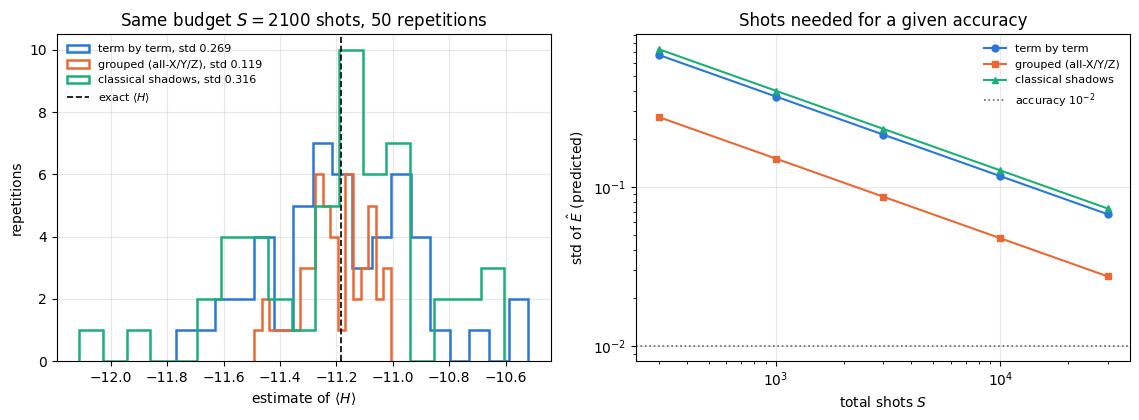


shots to reach a standard error of 0.01 on the energy:
              term by term:    1.367e+06
       grouped (all-X/Y/Z):    2.268e+05
         classical shadows:    1.614e+06


In [7]:
# ==============================================================================
# STEP 4: simulating the three protocols, many independent repetitions
# ==============================================================================
R_REP = 50                                     # independent repetitions of the whole protocol
M_GROUP = S_TOT // G_SETTINGS                  # shots per setting
M_TERM = S_TOT // T_TERMS                      # shots per term


def sample_shots(key, psi, n_shots, basis, chunk=20000):
    """`n_shots` measurements of every qubit in the SAME basis string, drawn in chunks.

    JAX  `jax.random.categorical` broadcasts the 2^N log-probabilities to (shots, 2^N); chunking keeps that
         intermediate bounded no matter how many shots the protocol asks for.
    """
    out, done = [], 0
    while done < n_shots:
        c = min(chunk, n_shots - done)
        out.append(sample_bitstrings(jax.random.fold_in(key, done), psi, c, bases=basis))
        done += c
    return jnp.concatenate(out)


@partial(jax.jit, static_argnums=(2,))
def shot_values(bits, digits, n_qubits):
    """+-1 value of every Pauli string for every shot of a setting that measured all of them.

    MATH  v_m(P) = prod_{q in supp(P)} (1 - 2 b_mq)    -- valid only when the setting satisfies Eq. (3).
    IMPL  for each qubit multiply by s_q where the string's digit is non-zero, by 1 where it is I.
    """
    s = (1 - 2 * bits).astype(RDTYPE)
    out = jnp.ones((bits.shape[0], digits.shape[0]), dtype=RDTYPE)
    for q in range(n_qubits):
        out = out * jnp.where(digits[:, q][None, :] == 0, 1.0, s[:, q][:, None])
    return out


# --- protocol 1: term by term ------------------------------------------------------------------
key = jax.random.PRNGKey(2024)
E_term = np.zeros(R_REP)
for p in "XYZ":
    idx = GROUPS[p]
    if not idx:
        continue
    bits = sample_shots(jax.random.fold_in(key, ord(p)), psi_vqe, R_REP * len(idx) * M_TERM, p * N_SITES)
    v = np.asarray(shot_values(bits, DIGITS[jnp.asarray(idx)], N_SITES))       # (R*n_g*m, n_g)
    v = v.reshape(R_REP, len(idx), M_TERM, len(idx))
    for j, t in enumerate(idx):                                               # term j uses only ITS OWN shots
        E_term += COEFFS[t] * v[:, j, :, j].mean(axis=1)

# --- protocol 2: grouped settings --------------------------------------------------------------
E_group = np.zeros(R_REP)
for p in "XYZ":
    idx = GROUPS[p]
    if not idx:
        continue
    bits = sample_shots(jax.random.fold_in(key, 100 + ord(p)), psi_vqe, R_REP * M_GROUP, p * N_SITES)
    v = np.asarray(shot_values(bits, DIGITS[jnp.asarray(idx)], N_SITES)).reshape(R_REP, M_GROUP, len(idx))
    E_group += (v @ COEFFS[idx]).mean(axis=1)                                 # one partial energy per shot

# --- protocol 3: classical shadows -------------------------------------------------------------
t0 = time.perf_counter()
bases_s, bits_s = collect_shadows(jax.random.PRNGKey(7), psi_vqe, R_REP * S_TOT)
vals_s = snapshot_values(bases_s, bits_s, DIGITS)
E_shadow = np.asarray((vals_s @ jnp.asarray(COEFFS)).reshape(R_REP, S_TOT).mean(axis=1))
print(f"collected {R_REP * S_TOT} snapshots in {time.perf_counter() - t0:.1f} s")

print(f"\n{R_REP} independent repetitions, total budget S = {S_TOT} shots each; exact <H> = {E_vqe:.5f}")
print(f"{'strategy':>24s} {'shots used':>11s} {'mean of estimates':>19s} {'measured std':>13s} "
      f"{'predicted std':>14s} {'ratio':>7s}")
for lab, est, v, used in (("term by term", E_term, var_term, T_TERMS * M_TERM),
                          ("grouped (all-X/Y/Z)", E_group, var_group, G_SETTINGS * M_GROUP),
                          ("classical shadows", E_shadow, var_shadow, S_TOT)):
    pred = np.sqrt(v / S_TOT)
    print(f"{lab:>24s} {used:11d} {est.mean():19.5f} {est.std():13.4f} {pred:14.4f} {est.std() / pred:7.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
for j, (lab, est) in enumerate((("term by term", E_term), ("grouped (all-X/Y/Z)", E_group),
                                ("classical shadows", E_shadow))):
    axes[0].hist(est, bins=18, histtype="step", lw=1.8, color=PALETTE[j], label=f"{lab}, std {est.std():.3f}")
axes[0].axvline(E_vqe, color="k", ls="--", lw=1.2, label=r"exact $\langle H\rangle$")
axes[0].set_xlabel(r"estimate of $\langle H\rangle$"); axes[0].set_ylabel("repetitions")
axes[0].set_title(f"Same budget $S={S_TOT}$ shots, {R_REP} repetitions"); axes[0].legend(fontsize=8)

S_GRID = np.array([300, 1000, 3000, 10000, 30000])
for j, (lab, v) in enumerate((("term by term", var_term), ("grouped (all-X/Y/Z)", var_group),
                              ("classical shadows", var_shadow))):
    axes[1].loglog(S_GRID, np.sqrt(v / S_GRID), MARKERS[j] + "-", ms=5, color=PALETTE[j], label=lab)
axes[1].axhline(1e-2, color="0.4", ls=":", lw=1.2, label=r"accuracy $10^{-2}$")
axes[1].set_xlabel("total shots $S$"); axes[1].set_ylabel(r"std of $\hat E$ (predicted)")
axes[1].set_title("Shots needed for a given accuracy"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f"\nshots to reach a standard error of 0.01 on the energy:")
for lab, v in (("term by term", var_term), ("grouped (all-X/Y/Z)", var_group), ("classical shadows", var_shadow)):
    print(f"  {lab:>24s}: {v / 1e-4:12.3e}")

### 6.2 What the numbers say

**All three predictions are confirmed.** Over 50 independent repetitions at $S=2100$ shots the measured standard
deviations are $0.269$, $0.119$ and $0.316$ against the predicted $0.255$, $0.104$ and $0.277$ — ratios of $1.05$,
$1.15$ and $1.14$. A standard deviation estimated from $50$ samples carries about $10\%$ of its own uncertainty, so
all three agree within one to one and a half standard errors, and the *ordering* and the *factors between the
strategies* are reproduced exactly. All three estimators are unbiased: their means sit within a fraction of a
standard error of the exact $\langle H\rangle=-11.185$.

**Grouping wins, by a factor of six against term-by-term and seven against shadows.** In variance at equal budget,
$136.7:22.7:161.4$. Translated into the currency that matters, the number of runs of the machine needed for a
standard error of $10^{-2}$ on the energy: $2.3\cdot10^{5}$ for the grouped protocol against $1.4\cdot10^{6}$ and
$1.6\cdot10^{6}$ for the other two. For a **fixed, known** local Hamiltonian, grouping is the right answer and it is
not close.

**The counting argument is not the whole story.** Naive counting predicts
$\mathrm{Var}_{\text{term}}/\mathrm{Var}_{\text{group}}=T/G=21/3=7$; the measured ratio is $6.03$. The missing
factor is the covariance of Eq. (6): the sum of the *individual* term variances is $6.51$, while the sum of the
grouped variances $\sum_g\mathrm{Var}(A_g)$ is $7.56$ — the covariances between terms measured in the same shot are
**positive** in aggregate here and inflate the grouped variance by $16\%$. Grouping still wins overwhelmingly, but by
a smaller factor than the term count suggests, and only a calculation (or a simulation) that keeps the covariances
can say by how much.

**Where the grouped variance lives is not where the terms are.** The per-setting contributions are $1.43$ (all-$X$,
eleven terms), $4.97$ (all-$Y$, five terms) and $1.16$ (all-$Z$, five terms). The $X$ setting carries twice as many
terms as the other two together and contributes least, because the state of Section 5 is nearly polarised along $x$:
$\lvert\langle X_q\rangle\rvert\approx0.98$ and $\langle X_qX_{q+1}\rangle\approx0.98$, so each of those
measurements is nearly deterministic and its variance $1-\langle P\rangle^2$ is small. The $Y$ correlators, with
$\langle YY\rangle\approx0.15$, are the noisy ones. **The measurement cost of a Hamiltonian depends on the state
being measured**, which is why it changes during a VQE run.

**Shadows are the most expensive of the three here, and that is the expected price of ignorance.** They pay the
$3^k$ of Eq. (4) on every one of the $15$ weight-2 terms, and the compensating factor — one data set serving every
observable — buys nothing when the observable list is a single known Hamiltonian. Section 7 changes the question.

## 7. One data set, many observables

The comparison of Section 6 was for a *fixed, known* Hamiltonian, which is the situation grouping is designed for.
The situation shadows are designed for is different: many observables, not all known in advance. Notebook 42 tracked
nine quantities; six of them are observables — the mean magnetisations $\langle X\rangle,\langle Y\rangle,\langle
Z\rangle$ and the mean bond correlators $\langle XX\rangle,\langle YY\rangle,\langle ZZ\rangle$ — built from
$3N+3(N-1)=33$ Pauli strings at $N=6$. We estimate all of them from the **same** shadow data set, and compare with
what the three grouped settings would give at the same total number of shots.

The comparison is predictable from the variance formulas, and it is worth writing down before measuring. For a
single weight-$k$ string $P$ at a total budget $S$:

* the grouped protocol measures $P$ in exactly one of its $G=3$ settings, which receives $S/3$ shots, and a shot
  there returns a $\pm1$ value, so $\mathrm{Var}_{\text{group}}=3\bigl(1-\langle P\rangle^2\bigr)/S$;
* shadows use all $S$ snapshots but pay the $3^k$ of Eq. (4), so
  $\mathrm{Var}_{\text{shadow}}=\bigl(3^k-\langle P\rangle^2\bigr)/S$.

The ratio is therefore

$$\frac{\mathrm{Var}_{\text{shadow}}}{\mathrm{Var}_{\text{group}}}
  =\frac{3^{k}-\langle P\rangle^{2}}{3\bigl(1-\langle P\rangle^{2}\bigr)} , \tag{10}$$

and it has two very different limits. For an observable with $\langle P\rangle\approx0$ it is $3^{k-1}$: shadows are
on par for single-site magnetisations and a factor of three in variance behind for bond correlators. But as
$\lvert\langle P\rangle\rvert\to1$ the denominator vanishes while the numerator does not, and the ratio **diverges**.
A dedicated setting measuring an almost deterministic observable gets it almost for free — every shot returns the
same sign — whereas a shadow data set still pays the full $3^k$ for the snapshots that happened to measure the wrong
axes. The state of Section 5 is nearly polarised, with $\langle X_q\rangle\approx-0.98$, so Eq. (10) predicts a
large ratio for the $X$-type observables and a modest one for the rest. The measurement below checks Eq. (10)
observable by observable.

20000 snapshots -> all 33 Pauli strings of the panel (2.7 s); none of them was chosen before the data were taken

observable     exact        shadow mean  bootstrap sd  median of means   deviation


       <X>   -0.9807      -0.9788 +- 0.0042        0.0041          -0.9815    +0.47 sd
       <Y>   +0.0003      -0.0077 +- 0.0053        0.0051          -0.0128    -1.51 sd


       <Z>   -0.0002      -0.0042 +- 0.0048        0.0052          +0.0005    -0.85 sd


      <XX>   +0.9828      +0.9785 +- 0.0106        0.0104          +0.9891    -0.40 sd
      <YY>   +0.1493      +0.1572 +- 0.0096        0.0100          +0.1677    +0.83 sd


      <ZZ>   -0.1439      -0.1489 +- 0.0094        0.0097          -0.1482    -0.52 sd

CHECKPOINT all 33 strings: largest deviation 3.01 standard errors, mean |deviation| 0.85 sd (expect ~0.8 for unbiased Gaussian errors)

standard error at S = 20000 shots: shadows (measured and predicted) vs the 3-setting protocol
observable  k  shadow sd (meas.)  shadow sd (pred.)  grouped sd (pred.)   ratio
       <X>  1            0.00416            0.00412             0.00098    4.26
       <Y>  1            0.00525            0.00500             0.00500    1.05
       <Z>  1            0.00476            0.00500             0.00500    0.95
      <XX>  2            0.01063            0.00896             0.00101   10.50
      <YY>  2            0.00962            0.00947             0.00541    1.78
      <ZZ>  2            0.00944            0.00948             0.00542    1.74


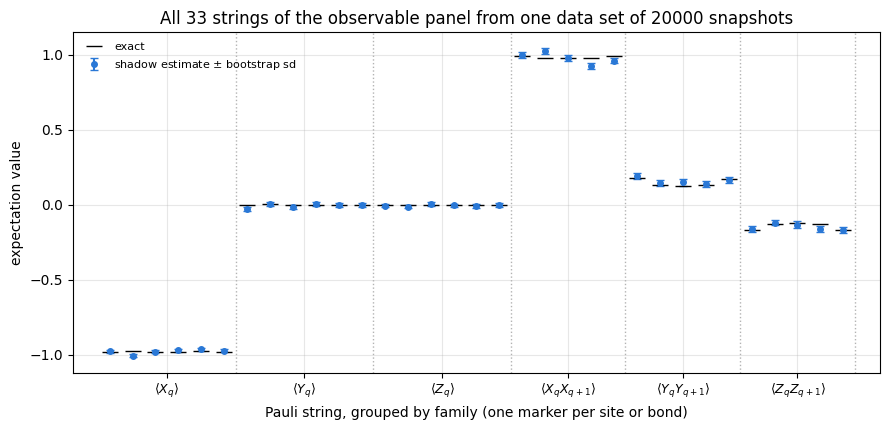

In [8]:
# ==============================================================================
# STEP 5: the whole observable panel of notebook 42, from one shadow data set
# ==============================================================================
M_PANEL, N_BOOT = 20000, 200
panel_labels, panel_kind = [], []
for p in "XYZ":
    for q in range(N_SITES):
        panel_labels.append("I" * q + p + "I" * (N_SITES - q - 1)); panel_kind.append(f"<{p}>")
for p in "XYZ":
    for q in range(N_SITES - 1):
        panel_labels.append("I" * q + p + p + "I" * (N_SITES - q - 2)); panel_kind.append(f"<{p}{p}>")
panel_dig = pauli_digits(panel_labels)
panel_exact = np.array([expect_label(psi_vqe, lab) for lab in panel_labels])

t0 = time.perf_counter()
bases_p, bits_p = collect_shadows(jax.random.PRNGKey(31), psi_vqe, M_PANEL)
vals_p = snapshot_values(bases_p, bits_p, panel_dig)
panel_mean = np.asarray(vals_p.mean(0))
panel_sem = np.asarray(vals_p.std(0) / np.sqrt(M_PANEL))
panel_boot = np.asarray(bootstrap_std(jax.random.PRNGKey(32), vals_p, N_BOOT))
panel_mom = np.asarray(median_of_means(vals_p, 9))
print(f"{M_PANEL} snapshots -> all {len(panel_labels)} Pauli strings of the panel "
      f"({time.perf_counter() - t0:.1f} s); none of them was chosen before the data were taken")

print(f"\n{'observable':>10s} {'exact':>9s} {'shadow mean':>18s} {'bootstrap sd':>13s} {'median of means':>16s} "
      f"{'deviation':>11s}")
groups_panel = {}
for kind in ("<X>", "<Y>", "<Z>", "<XX>", "<YY>", "<ZZ>"):
    sel = [i for i, k in enumerate(panel_kind) if k == kind]
    groups_panel[kind] = sel
    ex = panel_exact[sel].mean()
    est = panel_mean[sel].mean()
    # the mean over sites of correlated estimators: build its per-snapshot value and bootstrap that
    per_snap = np.asarray(vals_p[:, jnp.asarray(sel)]).mean(axis=1)
    sem = per_snap.std() / np.sqrt(M_PANEL)
    boot = float(bootstrap_std(jax.random.PRNGKey(33), jnp.asarray(per_snap)[:, None], N_BOOT)[0])
    mom = float(median_of_means(jnp.asarray(per_snap)[:, None], 9)[0])
    print(f"{kind:>10s} {ex:+9.4f} {est:+12.4f} +- {sem:.4f} {boot:13.4f} {mom:+16.4f} "
          f"{(est - ex) / sem:+8.2f} sd")

dev = np.abs(panel_mean - panel_exact) / panel_sem
print(f"\nCHECKPOINT all {len(panel_labels)} strings: largest deviation {dev.max():.2f} standard errors, "
      f"mean |deviation| {dev.mean():.2f} sd (expect ~0.8 for unbiased Gaussian errors)")
assert dev.max() < 5.0

# --- what the grouped protocol would give at the same total budget ------------------------------
print(f"\nstandard error at S = {M_PANEL} shots: shadows (measured and predicted) vs the 3-setting protocol")
print(f"{'observable':>10s} {'k':>2s} {'shadow sd (meas.)':>18s} {'shadow sd (pred.)':>18s} "
      f"{'grouped sd (pred.)':>19s} {'ratio':>7s}")
for kind in ("<X>", "<Y>", "<Z>", "<XX>", "<YY>", "<ZZ>"):
    sel = groups_panel[kind]
    k = 1 if len(kind) == 3 else 2
    ex = panel_exact[sel]
    # per-site/bond average of correlated estimators -> use the measured per-snapshot variance
    per_snap = np.asarray(vals_p[:, jnp.asarray(sel)]).mean(axis=1)
    sd_meas = per_snap.std() / np.sqrt(M_PANEL)
    sd_pred = np.sqrt(np.mean(3.0 ** k - ex ** 2) / len(sel) / M_PANEL)
    sd_group = np.sqrt(3 * np.mean(1 - ex ** 2) / len(sel) / M_PANEL)
    print(f"{kind:>10s} {k:2d} {sd_meas:18.5f} {sd_pred:18.5f} {sd_group:19.5f} {sd_meas / sd_group:7.2f}")

fig, ax = plt.subplots(figsize=(9.0, 4.4))
xs = np.arange(len(panel_labels))
ax.errorbar(xs, panel_mean, yerr=panel_boot, fmt="o", ms=4, color=PALETTE[0], capsize=3,
            label=r"shadow estimate $\pm$ bootstrap sd")
ax.plot(xs, panel_exact, "k_", ms=12, label="exact")
KIND_TEX = {"<X>": r"$\langle X_q\rangle$", "<Y>": r"$\langle Y_q\rangle$", "<Z>": r"$\langle Z_q\rangle$",
            "<XX>": r"$\langle X_qX_{q+1}\rangle$", "<YY>": r"$\langle Y_qY_{q+1}\rangle$",
            "<ZZ>": r"$\langle Z_qZ_{q+1}\rangle$"}
centres, names_tex = [], []
for kind in ("<X>", "<Y>", "<Z>", "<XX>", "<YY>", "<ZZ>"):
    sel = groups_panel[kind]
    centres.append(np.mean(sel)); names_tex.append(KIND_TEX[kind])
    ax.axvline(sel[-1] + 0.5, color="0.7", lw=1, ls=":")
ax.set_xticks(centres); ax.set_xticklabels(names_tex, fontsize=9)
ax.set_xlabel("Pauli string, grouped by family (one marker per site or bond)")
ax.set_ylabel("expectation value")
ax.set_title(f"All {len(panel_labels)} strings of the observable panel from one data set of {M_PANEL} snapshots")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Thirty-three Pauli strings, one data set, no prior decision.** The largest deviation from the exact value over the
$33$ strings is $3.0$ standard errors and the mean absolute deviation is $0.85$ — against the $0.8$ expected for
unbiased Gaussian errors, the small excess being the correlation between estimates built from the same snapshots.
The bootstrap standard deviations reproduce the analytic $\sigma/\sqrt M$ to the third digit for every one of the
six averaged observables, as they must for a plain sample mean; they earn their keep in Section 11, where the
quantity is not a sample mean.

**Equation (10) is confirmed, including the part that contradicts the naive expectation.** The last column of the
second table is the ratio of the shadow standard error to the grouped one:

* $\langle Y\rangle$ and $\langle Z\rangle$, weight $1$ with $\langle P\rangle\approx0$: ratios $1.05$ and $0.95$ —
  the two strategies are **equally good**, as the $3^{k-1}=1$ limit of Eq. (10) says;
* $\langle YY\rangle$ and $\langle ZZ\rangle$, weight $2$ with $\langle P\rangle\approx0.15$ and $-0.14$: ratios
  $1.78$ and $1.74$, against the $\sqrt{3^{k-1}}=\sqrt3=1.73$ of the same limit;
* $\langle X\rangle$ and $\langle XX\rangle$, whose expectation values are $-0.98$ and $+0.98$: ratios $4.3$ and
  $10.5$. This is the divergent limit of Eq. (10). A dedicated $X$ setting measuring an almost deterministic
  observable gets it for almost nothing — its variance $1-\langle P\rangle^2\approx0.04$ — while the shadow
  estimator still pays $3^k$ for the snapshots that measured the wrong axes.

So the honest summary is that **shadows are never cheaper per observable**; they range from equally good to an order
of magnitude worse in standard error, depending on $k$ and on how close $\langle P\rangle$ is to $\pm1$. What they
buy is elsewhere: the data set was collected before any of these $33$ strings was named, and estimating a
thirty-fourth — say $\langle X_0Y_2Z_4\rangle$ — costs nothing extra, whereas the grouped protocol would need a new
setting and a new experiment. The trade is **variance for adaptivity**, and the rigorous version of that statement
is the $\log K$ scaling of notebook 24, Eq. (8).

> **Numerical practice.** The predicted columns treat the $N$ site estimators (or $N-1$ bond estimators) that are
> averaged as independent. Equation (8) says they are not: neighbouring bond terms share a qubit, so their shadow
> estimators are positively correlated. That is visible in the table — the measured shadow error for
> $\langle XX\rangle$ is $0.0106$ against an independent-estimator prediction of $0.0090$, a $19\%$ excess —
> and it is one more reason to compute variances from the per-snapshot values rather than from a formula that
> assumes independence.

## 8. Shadow-estimated energies inside the optimisation loop

So far the state was fixed. Now the shadows drive the optimisation: at every iteration the cost is estimated from a
fresh data set of $M$ snapshots, and the optimiser never sees anything else. The gradient rule must therefore be one
that tolerates a noisy cost, which is SPSA (notebook 41): two cost evaluations per iteration, hence $2M$ snapshots
per iteration, whatever the number of angles.

Two changes with respect to the previous sections. First, the chain is shortened to $N=4$ with $L=2$ layers
($n=24$ angles): SPSA needs hundreds of iterations to converge and each iteration buys $2M$ snapshots, so a
meaningful budget scan is only affordable on a small system. Everything else — the Hamiltonian, the couplings, the
estimator — is unchanged. Second, the step size is measured rather than assumed, on the *exact* cost, because a step
size tuned for reverse-mode gradients has no reason to suit SPSA.

> **JAX practice.** The shadow cost has to live *inside* a `lax.scan` body that is itself `vmap`ped over restarts,
> so every snapshot of every restart of every iteration is generated in one compiled program. The memory that costs
> is (restarts) $\times$ $M$ $\times$ $2^N$ complex numbers for the batched rotated states; with eight restarts,
> $M=1024$ and $N=4$ that is $2\cdot10^{6}$ bytes. It is the quantity to check before raising $N$ or $M$: at $N=6$
> and $M=2048$ the same expression is already $1.6\cdot10^{7}$ bytes per evaluation.

The diagnostic plotted is the **exact** energy error of the current angles, which the optimiser never sees. Plotting
the noisy estimate instead would be the mistake analysed in Section 9.

In [9]:
# ==============================================================================
# STEP 6: a shadow-based cost function, jit-able and vmap-able
# ==============================================================================
ROTS = jnp.stack([_BASIS_ROT["X"], _BASIS_ROT["Y"], _BASIS_ROT["Z"]])


def shadow_snapshots(key, psi, n_snap):
    """`n_snap` random-Pauli snapshots of `psi`, generated inside a traced function.

    MATH   one snapshot = draw a basis code per qubit, rotate, sample ONE bit string from the Born rule
    IMPL   this is the engine's `collect_pauli_shadows` written out, so that it can be inlined in a training
           loop without the Python-level chunking of `collect_shadows` (which cannot be traced).
    COST   O(M N 2^N) time, O(M 2^N) memory.
    """
    N = psi.ndim

    def one(k):
        kb, ks = jax.random.split(k)
        bases = jax.random.randint(kb, (N,), 0, 3)
        phi = psi
        for q in range(N):
            phi = apply_gate(phi, ROTS[bases[q]], [q])
        logp = jnp.log(jnp.clip(jnp.abs(phi.reshape(-1)) ** 2, 1e-300, None))
        idx = jax.random.categorical(ks, logp)
        return bases, (idx >> jnp.arange(N - 1, -1, -1)) & 1

    return jax.vmap(one)(jax.random.split(key, n_snap))


def shadow_energy(key, psi, n_snap, digits, coeffs):
    """Energy estimate of `psi` from `n_snap` fresh snapshots: E_hat = (1/M) sum_m sum_t c_t o_m(P_t)."""
    bases, bits = shadow_snapshots(key, psi, n_snap)
    return jnp.mean(snapshot_values(bases, bits, digits) @ coeffs)


# --- the smaller chain used for the in-loop study ------------------------------------------------
N_LOOP, L_LOOP = 4, 2
n_loop = hea_num_params(N_LOOP, L_LOOP)
terms_loop = model_terms(N_LOOP, c_model)
E0_loop, psi0_loop = lanczos_ground_state(terms_loop, N_LOOP)
psi0_loop = psi0_loop / jnp.linalg.norm(psi0_loop)
LABELS_L, COEFFS_L = hamiltonian_pauli_list(N_LOOP, MODELS[MODEL])
DIG_L, COEF_L = pauli_digits(LABELS_L), jnp.asarray(COEFFS_L)
GROUPS_L = {p: [t for t, lab in enumerate(LABELS_L) if set(lab) - {"I"} == {p}] for p in "XYZ"}
cost_loop = jax.jit(lambda t: energy(terms_loop, hardware_efficient_ansatz(t, N_LOOP, L_LOOP)))
err_loop = jax.jit(lambda t: cost_loop(t) - E0_loop)
print(f"in-loop system: {MODEL} chain, N={N_LOOP}, L={L_LOOP}, n={n_loop} angles, "
      f"T={len(LABELS_L)} Pauli terms; exact E_0 = {E0_loop:.6f}")

# --- CHECKPOINT: the in-loop estimator is unbiased and its spread follows Eqs. (7) and (8) --------
M_CHK = 60000
bases_c, bits_c = collect_shadows(jax.random.PRNGKey(55), psi0_loop, M_CHK)
e_per_snap = np.asarray(snapshot_values(bases_c, bits_c, DIG_L) @ COEF_L)
PRED_L = predicted_variances(psi0_loop, LABELS_L, COEFFS_L, GROUPS_L)
print(f"\nexact E of the state measured: {E0_loop:.6f};   one data set of {M_CHK} snapshots cut into blocks")
print(f"{'block size M':>13s} {'blocks':>7s} {'mean of block means':>21s} {'std of block means':>20s} "
      f"{'predicted std':>14s}")
for M in (128, 512, 2048):
    nb_ = M_CHK // M
    blocks = e_per_snap[: nb_ * M].reshape(nb_, M).mean(axis=1)
    print(f"{M:13d} {nb_:7d} {blocks.mean():21.5f} {blocks.std():20.5f} "
          f"{np.sqrt(PRED_L['shadow'] / M):14.5f}")
print(f"single-snapshot variance: measured {e_per_snap.var():.2f}, predicted by Eqs. (7) and (8) "
      f"{PRED_L['shadow']:.2f}")
assert abs(e_per_snap.mean() - E0_loop) < 5 * e_per_snap.std() / np.sqrt(M_CHK)

in-loop system: XXZ chain, N=4, L=2, n=24 angles, T=13 Pauli terms; exact E_0 = -7.124149



exact E of the state measured: -7.124149;   one data set of 60000 snapshots cut into blocks
 block size M  blocks   mean of block means   std of block means  predicted std
          128     468              -7.18707              0.80107        0.86625
          512     117              -7.18707              0.39274        0.43312
         2048      29              -7.19377              0.20790        0.21656
single-snapshot variance: measured 96.24, predicted by Eqs. (7) and (8) 96.05


In [10]:
# ==============================================================================
# STEP 7: the SPSA step size, measured on the exact cost
# ==============================================================================
def grad_spsa_exact(cost, c=0.2, gamma=0.101):
    """SPSA gradient rule with Spall's probe radius c_k = c/k^gamma and an exact cost (notebook 41)."""
    def rule(theta, key, k):
        c_k = c / k ** gamma
        delta = jax.random.rademacher(key, theta.shape).astype(theta.dtype)
        return (cost(theta + c_k * delta) - cost(theta - c_k * delta)) / (2 * c_k) * delta
    return rule


def grad_spsa_shadow(n_snap, c=0.2, gamma=0.101):
    """The same rule with both cost evaluations replaced by shadow estimates from `n_snap` snapshots."""
    def rule(theta, key, k):
        c_k = c / k ** gamma
        kd, kp, km = jax.random.split(key, 3)
        delta = jax.random.rademacher(kd, theta.shape).astype(theta.dtype)
        cp = shadow_energy(kp, hardware_efficient_ansatz(theta + c_k * delta, N_LOOP, L_LOOP),
                           n_snap, DIG_L, COEF_L)
        cm = shadow_energy(km, hardware_efficient_ansatz(theta - c_k * delta, N_LOOP, L_LOOP),
                           n_snap, DIG_L, COEF_L)
        return (cp - cm) / (2 * c_k) * delta
    return rule


R_LOOP, T_LOOP = 6, 500
th_l, ks_l = random_starts(R_LOOP, n_loop, seed=301)
LR_GRID_SPSA = jnp.asarray([0.02, 0.05, 0.1, 0.2, 0.4], dtype=RDTYPE)
t0 = time.perf_counter()
H_lr = np.asarray(jax.block_until_ready(jax.jit(jax.vmap(lambda lr: jax.vmap(lambda t, k: train(
    t, k, grad_spsa_exact(cost_loop), opt_adam(lr), err_loop, T_LOOP)[1])(th_l, ks_l)))(LR_GRID_SPSA)))
print(f"SPSA step-size sweep on the EXACT cost ({len(LR_GRID_SPSA)} rates x {R_LOOP} restarts x {T_LOOP} "
      f"iterations, one compilation) in {time.perf_counter() - t0:.1f} s")
print(f"{'step size':>10s} {'median final E-E_0':>20s}")
med_lr = np.median(H_lr[:, :, -1], axis=1)
for j, lr in enumerate(np.asarray(LR_GRID_SPSA)):
    print(f"{lr:10.3g} {med_lr[j]:20.5f}")
LR_LOOP = float(np.asarray(LR_GRID_SPSA)[int(np.argmin(med_lr))])
h_spsa_exact = H_lr[int(np.argmin(med_lr))]
print(f"best SPSA step size: {LR_LOOP:g}")

SPSA step-size sweep on the EXACT cost (5 rates x 6 restarts x 500 iterations, one compilation) in 2.5 s
 step size   median final E-E_0
      0.02              0.05225
      0.05              0.12575
       0.1              0.69198
       0.2              1.61494
       0.4              4.31968
best SPSA step size: 0.02


3 shadow budgets + an exact-gradient reference, 6 restarts x 500 iterations, in 36.7 s

 snapshots/iteration  total snapshots  noise std of the cost   median final E-E_0      best
                 128            64000                 1.2251              1.00666   0.35896
                 512           256000                 0.6125              0.33694   0.27158
                2048          1024000                 0.3063              0.17209   0.14645
    exact cost, SPSA                0                 0.0000              0.05225   0.03444
exact gradient, Adam                0                 0.0000              0.00647   0.00240    (the ansatz floor)


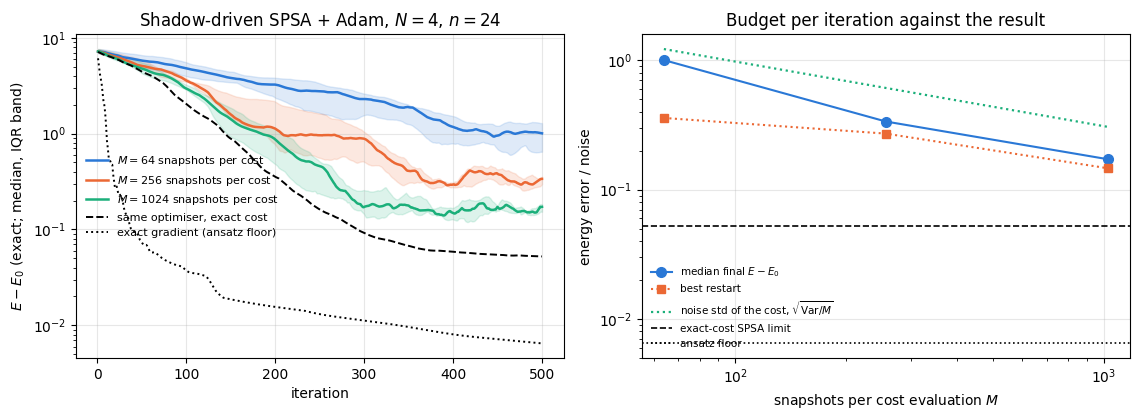

In [11]:
# ==============================================================================
# STEP 8: training with shadow-estimated costs, at three snapshot budgets
# ==============================================================================
SNAP_BUDGETS = (64, 256, 1024)
loop_hist, loop_theta = {}, {}
t0 = time.perf_counter()
for M in SNAP_BUDGETS:
    th_f, h = jax.block_until_ready(jax.jit(jax.vmap(lambda t, k: train(
        t, k, grad_spsa_shadow(M), opt_adam(LR_LOOP), err_loop, T_LOOP)))(th_l, ks_l))
    loop_hist[M] = np.asarray(h); loop_theta[M] = th_f
_, h_grad = jax.block_until_ready(jax.jit(jax.vmap(lambda t, k: train(
    t, k, grad_exact(cost_loop), opt_adam(0.1), err_loop, T_LOOP)))(th_l, ks_l))
h_grad = np.asarray(h_grad)
print(f"{len(SNAP_BUDGETS)} shadow budgets + an exact-gradient reference, {R_LOOP} restarts x {T_LOOP} "
      f"iterations, in {time.perf_counter() - t0:.1f} s")

print(f"\n{'snapshots/iteration':>20s} {'total snapshots':>16s} {'noise std of the cost':>22s} "
      f"{'median final E-E_0':>20s} {'best':>9s}")
for M in SNAP_BUDGETS:
    h = loop_hist[M]
    print(f"{2 * M:20d} {2 * M * T_LOOP:16d} {np.sqrt(PRED_L['shadow'] / M):22.4f} "
          f"{np.median(h[:, -1]):20.5f} {h[:, -1].min():9.5f}")
print(f"{'exact cost, SPSA':>20s} {0:16d} {0.0:22.4f} {np.median(h_spsa_exact[:, -1]):20.5f} "
      f"{h_spsa_exact[:, -1].min():9.5f}")
print(f"{'exact gradient, Adam':>20s} {0:16d} {0.0:22.4f} {np.median(h_grad[:, -1]):20.5f} "
      f"{h_grad[:, -1].min():9.5f}    (the ansatz floor)")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
it = np.arange(1, T_LOOP + 1)
for j, M in enumerate(SNAP_BUDGETS):
    lo, med, hi = bands(np.maximum(loop_hist[M], 1e-6))
    axes[0].fill_between(it, lo, hi, color=PALETTE[j], alpha=0.15)
    axes[0].semilogy(it, med, "-", lw=1.8, color=PALETTE[j], label=f"$M={M}$ snapshots per cost")
_, med_ref, _ = bands(np.maximum(h_spsa_exact, 1e-6))
axes[0].semilogy(it, med_ref, "k--", lw=1.4, label="same optimiser, exact cost")
_, med_g, _ = bands(np.maximum(h_grad, 1e-6))
axes[0].semilogy(it, med_g, "k:", lw=1.4, label="exact gradient (ansatz floor)")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel(r"$E-E_0$ (exact; median, IQR band)")
axes[0].set_title(f"Shadow-driven SPSA + Adam, $N={N_LOOP}$, $n={n_loop}$"); axes[0].legend(fontsize=8)

meds = [np.median(loop_hist[M][:, -1]) for M in SNAP_BUDGETS]
axes[1].loglog(SNAP_BUDGETS, meds, MARKERS[0] + "-", ms=7, color=PALETTE[0], label="median final $E-E_0$")
axes[1].loglog(SNAP_BUDGETS, [loop_hist[M][:, -1].min() for M in SNAP_BUDGETS], MARKERS[1] + ":", ms=6,
               color=PALETTE[1], label="best restart")
axes[1].loglog(SNAP_BUDGETS, [np.sqrt(PRED_L["shadow"] / M) for M in SNAP_BUDGETS], ":", color=PALETTE[2],
               lw=1.6, label=r"noise std of the cost, $\sqrt{\mathrm{Var}/M}$")
axes[1].axhline(np.median(h_spsa_exact[:, -1]), color="k", ls="--", lw=1.2, label="exact-cost SPSA limit")
axes[1].axhline(np.median(h_grad[:, -1]), color="k", ls=":", lw=1.2, label="ansatz floor")
axes[1].set_xlabel("snapshots per cost evaluation $M$"); axes[1].set_ylabel("energy error / noise")
axes[1].set_title("Budget per iteration against the result"); axes[1].legend(fontsize=7.5)
fig.tight_layout(); plt.show()

**Equation (8) is validated to two digits where it matters most.** The single-snapshot variance of the energy
estimator on the four-site chain is $96.24$ measured against $96.05$ predicted — a $0.2\%$ agreement for a formula
that had to account for the covariance of every one of the $13\times13$ pairs of Hamiltonian terms. The block-mean
spreads come out $4$ to $9\%$ *below* the prediction $\sqrt{\mathrm{Var}/M}$; with a few hundred blocks the sample
standard deviation of a heavy-tailed quantity is itself biased low, which is exactly the effect notebook 24 analysed
for the tails of the shadow estimator.

**The step size dominates everything, again.** Across the sweep the median final energy error runs from $0.052$ at
$\eta=0.02$ to $4.32$ at $\eta=0.4$ — a factor of $80$ from one hyper-parameter, measured on the *exact* cost so
that the shadows are not blamed for it. The step size that notebook 42 measured as best for Adam with reverse-mode
gradients, $0.4$, is the worst one here.

**The snapshot budget per iteration sets the answer, and it does so through the cost noise.** The median final
energy error is $1.01$ at $M=64$, $0.34$ at $M=256$ and $0.17$ at $M=1024$, while the standard deviation of the
cost estimate is $1.23$, $0.61$ and $0.31$. For the two larger budgets the final error is $0.55$ and $0.56$ times
the cost noise — the optimiser converges to a neighbourhood of the minimum whose size is set by the noise it cannot
see through, and a four-fold increase in snapshots halves both. The $M^{-1/2}$ law of the estimator therefore
propagates directly into an $M^{-1/2}$ law for the *result*, which is the worst possible scaling: an extra digit of
accuracy costs a hundred times the measurements.

**Two floors sit underneath.** The same optimiser with an exact cost reaches $0.052$, and the same circuit with an
exact gradient reaches $0.0065$. So of the $0.17$ achieved with $10^{6}$ snapshots per run, a factor of three is the
shadow noise, a further factor of eight is SPSA rather than a real gradient, and only the last $0.0065$ is the
ansatz. **Reporting the ansatz error of a shadow-driven VQE run without those two references would attribute to the
circuit what belongs to the measurement budget.**

## 9. Optimisation bias: the winner's curse

An optimiser driven by a noisy cost does not only converge more slowly; it converges to the wrong place, and it
**reports the wrong number**. The mechanism is elementary and completely general.

Let $\hat C_i=C_i+\varepsilon_i$ be noisy estimates of the true costs $C_i$ of several candidates (iterations,
restarts, hyper-parameter settings), with $\mathbb E[\varepsilon_i]=0$. Selecting the candidate with the smallest
$\hat C$ and reporting its $\hat C$ gives

$$\mathbb E\Bigl[\min_i\hat C_i\Bigr]\;\le\;\min_i\mathbb E\bigl[\hat C_i\bigr]=\min_iC_i , \tag{11}$$

because the minimum of a set of random variables is a concave function of them, so Jensen's inequality applies with
the inequality pointing downwards. The reported value is biased **below** the truth, and the bias grows with the
noise level and with the number of candidates. The selected candidate is also not necessarily the best one: it is
the one whose noise happened to be most favourable. In statistics this is the *winner's curse*; in a variational
calculation it is the reason a quoted energy can sit below the true ground energy and so appear to violate the
variational principle.

The cure is not subtle: **re-estimate the final answer with an independent data set**, large enough that its own
error bar is small, and quote that. The experiment below measures the size of the effect for the runs of Section 8.

independent verification with 30000 snapshots (own standard error 0.0566)

 M in loop  restart   in-loop estimate   independent      exact  bias of in-loop  truly best exact


        64        1           -7.50000      -6.71970   -6.76519         -0.73481          -6.76519


       256        3           -7.78711      -6.82955   -6.77261         -1.01450          -6.85257


      1024        3           -7.38135      -7.01605   -6.94617         -0.43518          -6.97770

mean over all 6 restarts of (in-loop estimate - exact energy), which should be zero for an unbiased estimator applied WITHOUT selection:
  M =    64: mean deviation -0.11410, deviation of the SELECTED restart -0.73481, selection picked restart 1 (truly best: 1)
  M =   256: mean deviation -0.22295, deviation of the SELECTED restart -1.01450, selection picked restart 3 (truly best: 5)
  M =  1024: mean deviation -0.01375, deviation of the SELECTED restart -0.43518, selection picked restart 3 (truly best: 5)

exact ground energy E_0 = -7.12415; an estimate below it signals the bias, not new physics


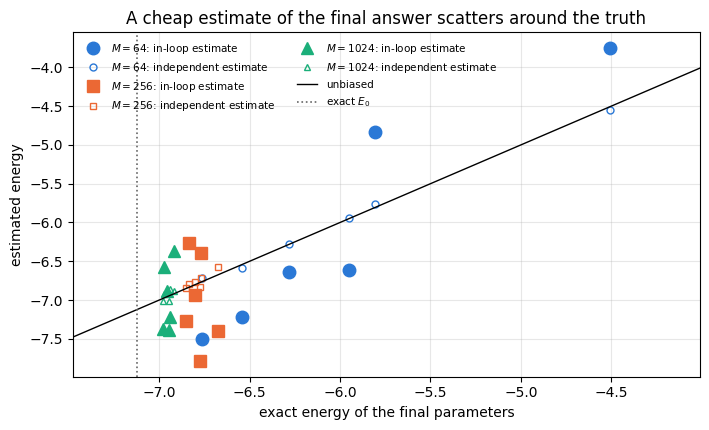

In [12]:
# ==============================================================================
# STEP 9: the reported energy versus the true energy of the selected parameters
# ==============================================================================
M_VERIFY = 30000                                # the independent, large data set
print(f"independent verification with {M_VERIFY} snapshots "
      f"(own standard error {np.sqrt(PRED_L['shadow'] / M_VERIFY):.4f})")
print(f"\n{'M in loop':>10s} {'restart':>8s} {'in-loop estimate':>18s} {'independent':>13s} {'exact':>10s} "
      f"{'bias of in-loop':>16s} {'truly best exact':>17s}")
bias_rows = []
for M in SNAP_BUDGETS:
    ests_loop, ests_ind, ex = [], [], []
    for r in range(R_LOOP):
        psi_r = hardware_efficient_ansatz(loop_theta[M][r], N_LOOP, L_LOOP)
        ests_loop.append(float(shadow_energy(jax.random.PRNGKey(900 + r), psi_r, M, DIG_L, COEF_L)))
        bb, tt = collect_shadows(jax.random.PRNGKey(1900 + r), psi_r, M_VERIFY)
        ests_ind.append(float((snapshot_values(bb, tt, DIG_L) @ COEF_L).mean()))
        ex.append(float(energy(terms_loop, psi_r)))
    ests_loop, ests_ind, ex = np.array(ests_loop), np.array(ests_ind), np.array(ex)
    r_sel, r_true = int(np.argmin(ests_loop)), int(np.argmin(ex))
    bias_rows.append((M, ests_loop, ests_ind, ex, r_sel, r_true))
    print(f"{M:10d} {r_sel:8d} {ests_loop[r_sel]:18.5f} {ests_ind[r_sel]:13.5f} {ex[r_sel]:10.5f} "
          f"{ests_loop[r_sel] - ex[r_sel]:16.5f} {ex[r_true]:17.5f}")
print(f"\nmean over all {R_LOOP} restarts of (in-loop estimate - exact energy), which should be zero "
      f"for an unbiased estimator applied WITHOUT selection:")
for M, el, ei, ex, r_sel, r_true in bias_rows:
    print(f"  M = {M:5d}: mean deviation {np.mean(el - ex):+.5f}, "
          f"deviation of the SELECTED restart {el[r_sel] - ex[r_sel]:+.5f}, "
          f"selection picked restart {r_sel} (truly best: {r_true})")
print(f"\nexact ground energy E_0 = {E0_loop:.5f}; an estimate below it signals the bias, not new physics")

fig, ax = plt.subplots(figsize=(7.2, 4.4))
for j, (M, el, ei, ex, r_sel, r_true) in enumerate(bias_rows):
    ax.plot(ex, el, MARKERS[j], ms=9, color=PALETTE[j], label=f"$M={M}$: in-loop estimate")
    ax.plot(ex, ei, MARKERS[j], ms=5, mfc="none", color=PALETTE[j], label=f"$M={M}$: independent estimate")
lims = [min(min(r[3]) for r in bias_rows) - 0.5, max(max(r[3]) for r in bias_rows) + 0.5]
ax.plot(lims, lims, "k-", lw=1, label="unbiased")
ax.axvline(E0_loop, color="0.4", ls=":", lw=1.2, label=r"exact $E_0$")
ax.set_xlim(*lims)
ax.set_xlabel(r"exact energy of the final parameters")
ax.set_ylabel("estimated energy")
ax.set_title("A cheap estimate of the final answer scatters around the truth")
ax.legend(fontsize=7.5, ncol=2)
fig.tight_layout(); plt.show()

**The effect is large and it points the predicted way.** For each budget the table reports the restart an
experimenter would select — the one with the lowest in-loop estimate — and what that estimate was worth. At $M=256$
the selected run reported $-7.787$ while its true energy is $-6.773$: the quoted number is too low by $1.01$, and it
is $0.66$ **below the exact ground energy** $E_0=-7.124$. Read without the exact reference, that run looks like a
violation of the variational principle. It is nothing of the sort; it is Eq. (11) at work. The bias shrinks with the
budget, $-0.73$, $-1.01$, $-0.44$ for $M=64,256,1024$, roughly in step with the cost noise, as it must.

**The bias comes from the selection, not from the estimator.** Averaged over *all* restarts, with no selection, the
deviation of the in-loop estimates from the exact energies is $-0.11$, $-0.22$ and $-0.014$, against standard errors
of the mean of $0.50$, $0.25$ and $0.13$ — consistent with zero, as an unbiased estimator requires. It is
$\min_i\hat C_i$ that is biased, not $\hat C_i$.

**The selected candidate is often not the best one.** At $M=256$ and $M=1024$ the selection picked restart $3$ while
the truly best restart was $5$; only at $M=64$ did the two coincide. Noise of the size of the differences between
candidates does not merely blur the ranking, it reorders it.

**The independent estimates are unbiased and cheap.** Re-measuring the selected parameters with $3\cdot10^{4}$ fresh
snapshots — a few percent of what the optimisation itself spent — gives $-6.720$, $-6.830$, $-7.016$ against exact
values of $-6.765$, $-6.773$, $-6.946$, within one or two of the $0.057$ standard error. In the figure the open
markers sit on the diagonal while the filled ones scatter below it.

> **Common pitfall.** Quoting the best cost value seen during training is the single most common way to overstate a
> variational result. The rule is: **select with the noisy data, report with fresh data.** The same applies to
> choosing hyper-parameters, ansätze or restarts — every selection made on noisy estimates needs an independent
> re-measurement before the number is quoted.

## 10. Derandomisation, biased ensembles and where this is going

The random Pauli ensemble of Section 3.4 is deliberately ignorant: it draws each basis uniformly, whatever the
Hamiltonian is. Two lines of work remove that ignorance while keeping the "one data set, many observables" property.

**Locally biased shadows** (Hadfield, Bravyi, Raymond and Mezzacapo, 2022) keep the measurement independent per
qubit but replace the uniform distribution over $\{X,Y,Z\}$ by a per-qubit distribution $\beta_q$ optimised for the
observables of interest; the inverse channel and the estimator change accordingly, and the variance for the target
set drops. **Derandomisation** (Huang, Kueng and Preskill, 2021) goes further and removes the randomness altogether:
given a target list of Pauli observables and a desired accuracy, a greedy algorithm chooses each measurement setting
deterministically so as to minimise a bound on the worst-case remaining confidence, producing a *schedule* rather
than a distribution. It provably never needs more measurements than the randomised scheme, and in the reported
benchmarks on molecular Hamiltonians it needs about an order of magnitude fewer, closing most of the gap to
problem-specific grouping while remaining applicable to a list of observables of arbitrary structure. Both methods
occupy the space between the two extremes measured in Section 6: fully problem-adapted grouping, which is optimal
for a known Hamiltonian and useless for anything else, and fully random shadows, which are agnostic and therefore
pay the $3^k$ of Eq. (4).

## 11. Certifying the prepared state end to end

The last step of an experiment: take the state that was prepared, spend one large measurement budget on it, and
report everything that is known about it with honest error bars. We certify the six-qubit variational state of
Section 5 — the one all the measurement studies were performed on — because it is the well-converged one; the
shadow-driven states of Section 8 were already re-measured independently in Section 9.

The error bars come from the **bootstrap** of notebook 24. The error bars come from the **bootstrap** of
Resample the snapshots with replacement, recompute, and take the spread: it is the right tool here because several
of the reported quantities (the mean correlators, the fidelity) are functions of the *same* snapshots and therefore
correlated.

The fidelity with the exact ground state deserves a comment. It is the expectation value of the projector
$\vert\psi_0\rangle\langle\psi_0\vert$, an $N$-body observable, and notebook 24 measured its single-snapshot second
moment to grow exponentially in $N$ for local shadows, reaching about $11$ per snapshot at $N=6$. A data set of
$5\cdot10^{4}$ snapshots therefore gives it an error bar near $0.015$ — acceptable here. At $N=20$ it would not be,
which is why fidelity estimation from local randomised measurements does not scale and global (Clifford) shadows
exist.

state to certify: the best of the 8 exact-gradient VQE restarts of Section 5, N=6
  exact E = -11.184801  (E - E_0 = 7.91e-03), exact F = 0.99904


collected 50000 verification snapshots in 1.3 s



              quantity      exact    shadow estimate  bootstrap sd  median of means    deviation


            energy <H>   -11.1848     -11.1862 +- 0.0568        0.0590         -11.2040     -0.02 sd


                   <X>    -0.9807      -0.9790 +- 0.0026        0.0028          -0.9796     +0.65 sd


...

                   <Z>    -0.0002      +0.0025 +- 0.0030        0.0033          +0.0009     +0.90 sd


                  <XX>    +0.9828      +0.9796 +- 0.0067        0.0066          +0.9747     -0.47 sd


                  <YY>    +0.1493      +0.1527 +- 0.0060        0.0059          +0.1507     +0.57 sd


                  <ZZ>    -0.1439      -0.1398 +- 0.0060        0.0057          -0.1413     +0.68 sd


  fidelity with the GS    +0.9990      +0.9922 +- 0.0141        0.0144          +1.0017     -0.48 sd

single-snapshot second moment of the fidelity estimator: 10.95; notebook 24 measured 11.52 for a PRODUCT target at N=6 and 8.63 for GHZ -- the base of the exponential growth is state-dependent, the growth itself is not
single-snapshot variance of the energy estimator: 161.56 (Eqs. (7) and (8) predict 161.38 for this state)


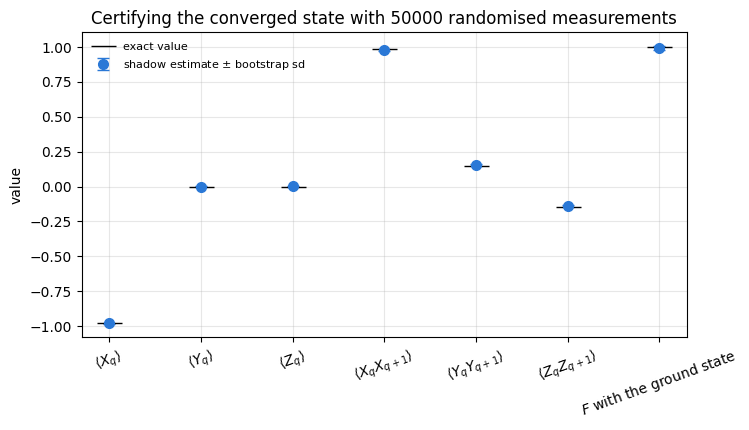

In [13]:
# ==============================================================================
# STEP 9: energy, correlators and fidelity of the converged state, with bootstrap errors
# ==============================================================================
M_FINAL = 50000
psi_final = psi_vqe                                   # the variational state of Section 5
print(f"state to certify: the best of the {R_ANS} exact-gradient VQE restarts of Section 5, N={N_SITES}")
print(f"  exact E = {float(energy(terms, psi_final)):.6f}  (E - E_0 = {float(energy(terms, psi_final)) - E0:.2e}), "
      f"exact F = {float(fidelity_pure(psi_exact, psi_final)):.5f}")

t0 = time.perf_counter()
bases_f, bits_f = collect_shadows(jax.random.PRNGKey(77), psi_final, M_FINAL)
print(f"collected {M_FINAL} verification snapshots in {time.perf_counter() - t0:.1f} s")

# --- the energy and the six panel observables ----------------------------------------------------
vals_H = snapshot_values(bases_f, bits_f, DIGITS) @ jnp.asarray(COEFFS)
vals_panel = snapshot_values(bases_f, bits_f, panel_dig)
rows_final = [("energy <H>", float(energy(terms, psi_final)), np.asarray(vals_H)[:, None])]

for kind in ("<X>", "<Y>", "<Z>", "<XX>", "<YY>", "<ZZ>"):
    sel = groups_panel[kind]
    exact_kind = float(np.mean([expect_label(psi_final, panel_labels[i]) for i in sel]))
    rows_final.append((kind, exact_kind, np.asarray(vals_panel[:, jnp.asarray(sel)]).mean(axis=1)[:, None]))


# --- the fidelity with the exact ground state, from the same snapshots ---------------------------
SNAP1 = jnp.stack([jnp.stack([3.0 * jnp.outer(ROTS[b].conj().T[:, s], ROTS[b].conj().T[:, s].conj()) - I2
                              for s in range(2)]) for b in range(3)])          # (3, 2, 2, 2)


def shadow_fidelity_local(bases, bits, psi_t, chunk=20000):
    """Single-snapshot estimates of <psi_t| rho |psi_t> from Pauli shadows (notebook 24, Step 6).

    MATH   o_m = <psi_t| (x)_q A_q^{(m)} |psi_t>,  A_q = 3 U^dag|b><b|U - 1 = SNAP1[basis, bit]
    IMPL   N apply_gate einsums and one inner product per snapshot; vmap over snapshots, in chunks.
    """
    N = psi_t.ndim

    def one(bb, ss):
        phi = psi_t
        for q in range(N):
            phi = apply_gate(phi, SNAP1[bb[q], ss[q]], [q])
        return jnp.real(jnp.vdot(psi_t, phi))

    f = jax.jit(jax.vmap(one))
    out, done = [], 0
    while done < bases.shape[0]:
        c = min(chunk, bases.shape[0] - done)
        out.append(f(bases[done:done + c], bits[done:done + c]))
        done += c
    return jnp.concatenate(out)


vals_F = shadow_fidelity_local(bases_f, bits_f, psi_exact)
rows_final.append(("fidelity with the GS", float(fidelity_pure(psi_exact, psi_final)),
                   np.asarray(vals_F)[:, None]))

print(f"\n{'quantity':>22s} {'exact':>10s} {'shadow estimate':>18s} {'bootstrap sd':>13s} "
      f"{'median of means':>16s} {'deviation':>12s}")
for name, ex, per_snap in rows_final:
    est = per_snap.mean()
    sem = per_snap.std() / np.sqrt(per_snap.shape[0])
    boot = float(bootstrap_std(jax.random.PRNGKey(78), jnp.asarray(per_snap), N_BOOT)[0])
    mom = float(median_of_means(jnp.asarray(per_snap), 9)[0])
    print(f"{name:>22s} {ex:+10.4f} {est:+12.4f} +- {sem:.4f} {boot:13.4f} {mom:+16.4f} "
          f"{(est - ex) / sem:+9.2f} sd")

print(f"\nsingle-snapshot second moment of the fidelity estimator: {float(jnp.mean(vals_F ** 2)):.2f}; "
      f"notebook 24 measured 11.52 for a PRODUCT target at N={N_SITES} and 8.63 for GHZ -- the base of the "
      f"exponential growth is state-dependent, the growth itself is not")
print(f"single-snapshot variance of the energy estimator: {float(jnp.var(vals_H)):.2f} "
      f"(Eqs. (7) and (8) predict {var_shadow:.2f} for this state)")

fig, ax = plt.subplots(figsize=(7.6, 4.4))
names = [r[0] for r in rows_final[1:]]
ex_v = np.array([r[1] for r in rows_final[1:]])
est_v = np.array([r[2].mean() for r in rows_final[1:]])
err_v = np.array([float(bootstrap_std(jax.random.PRNGKey(79), jnp.asarray(r[2]), N_BOOT)[0])
                  for r in rows_final[1:]])
xs = np.arange(len(names))
ax.errorbar(xs, est_v, yerr=err_v, fmt="o", ms=7, color=PALETTE[0], capsize=4,
            label=r"shadow estimate $\pm$ bootstrap sd")
ax.plot(xs, ex_v, "k_", ms=18, label="exact value")
ax.set_xticks(xs)
ax.set_xticklabels([KIND_TEX.get(nm, r"$F$ with the ground state") for nm in names], rotation=20)
ax.set_ylabel("value")
ax.set_title(f"Certifying the converged state with {M_FINAL} randomised measurements")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Everything agrees, and the error bars are honest.** All eight reported quantities sit within one standard error of
their exact values: the energy $-11.186\pm0.057$ against $-11.185$, the six averaged observables within $0.9$
standard errors, and the fidelity with the exact ground state $0.992\pm0.014$ against $0.9990$. The bootstrap
standard deviations agree with the analytic $\sigma/\sqrt M$ to the third digit for every entry, which is the
expected behaviour for sample means and the reason the bootstrap can be trusted for the quantities where no analytic
formula is at hand.

**Equation (8) again, on a different state and a different chain length.** The single-snapshot variance of the energy
estimator is $161.56$ measured against $161.38$ predicted — one part in a thousand. The derivation of Section 4.3,
covariances included, is exact.

**The fidelity is the expensive one.** Its single-snapshot second moment is $10.95$, an order of magnitude above the
$3^1=3$ of a single-site magnetisation, which is why $5\cdot10^{4}$ snapshots give it an error bar of $0.014$ while
the same data determine $\langle X\rangle$ to $0.003$. Notebook 24 measured this quantity growing exponentially in
$N$ — $11.52$ for a product target and $8.63$ for GHZ at $N=6$ — so the base depends on the state but the growth does
not. Certifying a twenty-qubit state by local randomised measurements is not possible at this cost, and that is the
boundary at which global (Clifford) shadows or direct fidelity estimation take over.

**What the whole pipeline delivered.** A circuit was trained, and then a single data set of integers — $2\times
5\cdot10^{4}\times6$ numbers, no amplitudes, no density matrix — was enough to report its energy, its magnetisation
profile, its bond correlators and its overlap with the target, each with an error bar, each agreeing with the exact
answer. That is what the method is for.

## 12. Key takeaways

* **A local Hamiltonian is a sum of $T=4N-3$ Pauli strings, but it needs only $G=3$ measurement settings.** The
  lower bound follows from one bond needing the three assignments $(X,X)$, $(Y,Y)$, $(Z,Z)$; the upper bound from
  measuring every qubit in $X$, then $Y$, then $Z$. The setting count is **independent of $N$** while the term count
  is not.
* **Three estimator variances, derived and then measured.** At a fixed budget $S$, Eqs. (5), (6) and (7)-(8) predict
  $S\,\mathrm{Var}=136.7$, $22.7$ and $161.4$ for term-by-term, grouped and shadow estimation of this chain's energy;
  the measured standard deviations over $50$ repetitions matched to within $5$, $15$ and $14\%$, i.e. within the
  uncertainty of a standard deviation estimated from $50$ samples.
* **For a fixed known Hamiltonian, grouping wins and it is not close**: $2.3\cdot10^{5}$ shots for a standard error
  of $10^{-2}$ against $1.4\cdot10^{6}$ and $1.6\cdot10^{6}$.
* **The covariance between terms measured in the same shot is a leading effect, not a correction.** Dropping it
  would predict a ratio $T/G=7$ between term-by-term and grouping; the true ratio is $6.03$, because the
  within-setting covariances inflate the grouped variance by $16\%$. For shadows the covariance formula
  $\mathrm{Cov}=3^{\lvert I\rvert}\langle P_tP_{t'}\rangle-\langle P_t\rangle\langle P_{t'}\rangle$, Eq. (8),
  reproduced the measured single-snapshot variance to $0.2\%$ on one state and $0.1\%$ on another.
* **The measurement cost depends on the state.** The all-$X$ setting carries eleven of the twenty-one terms and
  contributes $1.43$ of the grouped variance, while the all-$Y$ setting carries five terms and contributes $4.97$ —
  because the state is nearly polarised along $x$, which makes those measurements nearly deterministic.
* **Shadows are never cheaper per observable; they are adaptive.** Equation (10) gives the ratio
  $(3^k-\langle P\rangle^2)/(3(1-\langle P\rangle^2))$, measured as $1.05$ and $0.95$ for weight-1 observables with
  $\langle P\rangle\approx0$, $1.74$ to $1.78$ for weight-2 ones, and $4.3$ to $10.5$ for observables with
  $\lvert\langle P\rangle\rvert\approx0.98$. The compensation is that all $33$ strings of the observable panel came
  from one data set collected before any of them was named.
* **Inside the loop, the snapshot budget per iteration sets the achievable error through the cost noise.** Median
  final energy errors of $1.01$, $0.34$ and $0.17$ at $M=64$, $256$ and $1024$ against cost noise of $1.23$, $0.61$
  and $0.31$: the final error settled at $0.55$ times the noise, so accuracy improves only as $M^{-1/2}$.
* **Separate the three contributions before blaming the circuit.** With $10^{6}$ snapshots the shadow-driven run
  reached $0.17$; the same optimiser with an exact cost reached $0.052$; the same circuit with an exact gradient
  reached $0.0065$. Measurement noise, optimiser and ansatz each contributed a distinct factor.
* **A cost estimated from few measurements is unbiased; the *minimum* of several such costs is not.** Equation (11)
  predicts a downward bias, and the selected restart at $M=256$ reported $-7.787$ against a true $-6.773$ — a value
  $0.66$ below the exact ground energy. Averaged without selection the same estimates were unbiased to within their
  standard errors. Select with the noisy data, report with fresh data.
* **One data set of integers certifies the whole state.** $5\cdot10^{4}$ randomised measurements gave the energy,
  six averaged observables and the fidelity with the exact ground state, all within one standard error, with
  bootstrap error bars that reproduced the analytic ones. The fidelity was the expensive entry, with a
  single-snapshot second moment of $10.95$ against $3$ for a magnetisation — the exponential-in-$N$ cost that stops
  local shadows from certifying large states.

## 13. Exercises

1. ★ **The Ising count.** Repeat the derivation of Section 3.3 for the transverse-field Ising chain and for the
   Heisenberg chain with a longitudinal field $h_z\sum_qZ_q$. How many qubit-wise-commuting settings does each need,
   and which terms come for free?
2. ★ **Accuracy for a price.** Using the measured variances of Section 6, compute how many shots each of the three
   strategies needs for a standard error of $10^{-3}$ on the energy of this chain, and how that changes if the chain
   is twice as long (the variances are extensive — check that numerically).
3. ★★ **The covariance formula (extend the code).** Verify Eq. (8) directly: pick two overlapping bond terms, collect
   shadows, and compare the measured $\mathbb E[\hat o_t\hat o_{t'}]$ with $3^{\lvert I\rvert}\langle P_tP_{t'}\rangle$.
   Then repeat for two terms that disagree on a shared qubit and confirm that the product is identically zero.
4. ★★ **Locally biased shadows (extend the code).** Replace the uniform basis distribution by a per-qubit
   distribution $\beta_q$ and re-derive the estimator: the factor $3$ in Eq. (4) becomes $1/\beta_q$. Optimise
   $\beta$ for the XXZ Hamiltonian (hint: the $X$ terms outnumber the others) and measure the variance gain.
5. ★★ **Shots per iteration versus iterations (physics).** Section 8 fixed the iteration count and varied $M$. Fix
   the *total* snapshot budget instead and trade $M$ against the number of iterations. Where is the optimum, and does
   it move as the budget grows?
6. ★★ **Median of means in the loop.** Replace the sample mean of the shadow cost by a median of means with $G=9$
   groups and repeat Section 8. Does the more robust estimator help the optimiser, or does the loss of effective
   sample size hurt more?
7. ★★★ **Quantifying the winner's curse (physics).** For a fixed set of final parameters, draw many independent
   shadow estimates of the energy and measure $\mathbb E[\min_i\hat C_i]-\min_iC_i$ of Eq. (9) as a function of the
   number of candidates and of $M$. Compare with the Gaussian prediction $-\sigma\sqrt{2\ln R}$ for $R$ independent
   candidates.
8. ★★★ **A shadow-based gradient (extend the code).** Instead of estimating the cost and applying SPSA, estimate the
   parameter-shift gradient from shadows: each of the $2n$ shifted circuits needs its own data set. Derive the total
   snapshot cost per iteration, implement it, and compare with SPSA at equal total budget.

## 14. References

* H.-Y. Huang, R. Kueng and J. Preskill, *Predicting many properties of a quantum system from very few measurements*,
  Nat. Phys. **16**, 1050 (2020) — classical shadows, the estimator of Eq. (4) and its variance.
* H.-Y. Huang, R. Kueng and J. Preskill, *Efficient estimation of Pauli observables by derandomization*,
  Phys. Rev. Lett. **127**, 030503 (2021) — the derandomised schedule of Section 10.
* C. Hadfield, S. Bravyi, R. Raymond and A. Mezzacapo, *Measurements of quantum Hamiltonians with locally-biased
  classical shadows*, Commun. Math. Phys. **391**, 951 (2022) — biased local ensembles.
* V. Verteletskyi, T.-C. Yen and A. F. Izmaylov, *Measurement optimization in the variational quantum eigensolver
  using a minimum clique cover*, J. Chem. Phys. **152**, 124114 (2020) — grouping commuting terms as a graph-colouring
  problem.
* A. Peruzzo, J. McClean, P. Shadbolt, M.-H. Yung, X.-Q. Zhou, P. J. Love, A. Aspuru-Guzik and J. L. O'Brien,
  *A variational eigenvalue solver on a photonic quantum processor*, Nat. Commun. **5**, 4213 (2014) — the first VQE
  experiment, and the term-by-term measurement scheme of Section 3.2.
* J. Tilly, H. Chen, S. Cao, D. Picozzi, K. Setia, Y. Li, E. Grant, L. Wossnig, I. Rungger, G. H. Booth and
  J. Tennyson, *The variational quantum eigensolver: a review of methods and best practices*, Phys. Rep. **986**, 1
  (2022) — the measurement problem in context, with cost estimates for molecular Hamiltonians.
* J. C. Spall, *Multivariate stochastic approximation using a simultaneous perturbation gradient approximation*,
  IEEE Trans. Autom. Control **37**, 332 (1992) — the SPSA gradient rule used in Section 8.
* M. Cerezo, A. Arrasmith, R. Babbush, S. C. Benjamin, S. Endo, K. Fujii, J. R. McClean, K. Mitarai, X. Yuan,
  L. Cincio and P. J. Coles, *Variational quantum algorithms*, Nat. Rev. Phys. **3**, 625 (2021) — the review, with a
  section on measurement cost.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/